In [1]:
import subprocess, sys

for pkg in ['prophet', 'lightgbm']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error
from scipy.stats.mstats import winsorize
from scipy.optimize import minimize_scalar

In [2]:
# Load data
df_polis = pd.read_csv('Data_Polis.csv')
df_klaim = pd.read_csv('Data_Klaim.csv')

# Standardize column names
df_polis.columns = df_polis.columns.str.strip()
df_klaim.columns = df_klaim.columns.str.strip()

print("=" * 50)
print("DATA POLIS")
print("=" * 50)
print(f"Shape: {df_polis.shape}")
display(df_polis.head())
print(df_polis.info())

print("\n" + "=" * 50)
print("DATA KLAIM")
print("=" * 50)
print(f"Shape: {df_klaim.shape}")
display(df_klaim.head())
print(df_klaim.info())

DATA POLIS
Shape: (4096, 6)


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA
3,POL-0004,M-003,M,20140724,20160811,JAKARTA
4,POL-0005,M-001,F,19810114,20150828,JAKARTA


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Nomor Polis            4096 non-null   object
 1   Plan Code              4096 non-null   object
 2   Gender                 4096 non-null   object
 3   Tanggal Lahir          4096 non-null   int64 
 4   Tanggal Efektif Polis  4096 non-null   int64 
 5   Domisili               4096 non-null   object
dtypes: int64(2), object(4)
memory usage: 192.1+ KB
None

DATA KLAIM
Shape: (4627, 13)


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Claim ID                       4627 non-null   object 
 1   Nomor Polis                    4627 non-null   object 
 2   Reimburse/Cashless             4627 non-null   object 
 3   Inpatient/Outpatient           4590 non-null   object 
 4   ICD Diagnosis                  4621 non-null   object 
 5   ICD Description                4621 non-null   object 
 6   Status Klaim                   4627 non-null   object 
 7   Tanggal Pembayaran Klaim       4590 non-null   object 
 8   Tanggal Pasien Masuk RS        4627 non-null   object 
 9   Tanggal Pasien Keluar RS       4627 non-null   object 
 10  Nominal Klaim Yang Disetujui   4627 non-null   float64
 11  Nominal Biaya RS Yang Terjadi  4627 non-null   float64
 12  Lokasi RS                      4620 non-null   o

MISSING VALUES — DATA POLIS
Tidak ada missing value


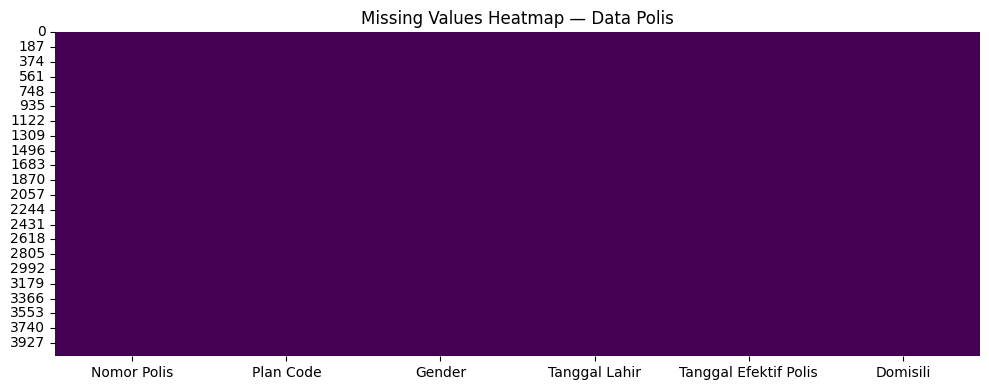


MISSING VALUES — DATA KLAIM
Inpatient/Outpatient        37
ICD Diagnosis                6
ICD Description              6
Tanggal Pembayaran Klaim    37
Lokasi RS                    7
dtype: int64


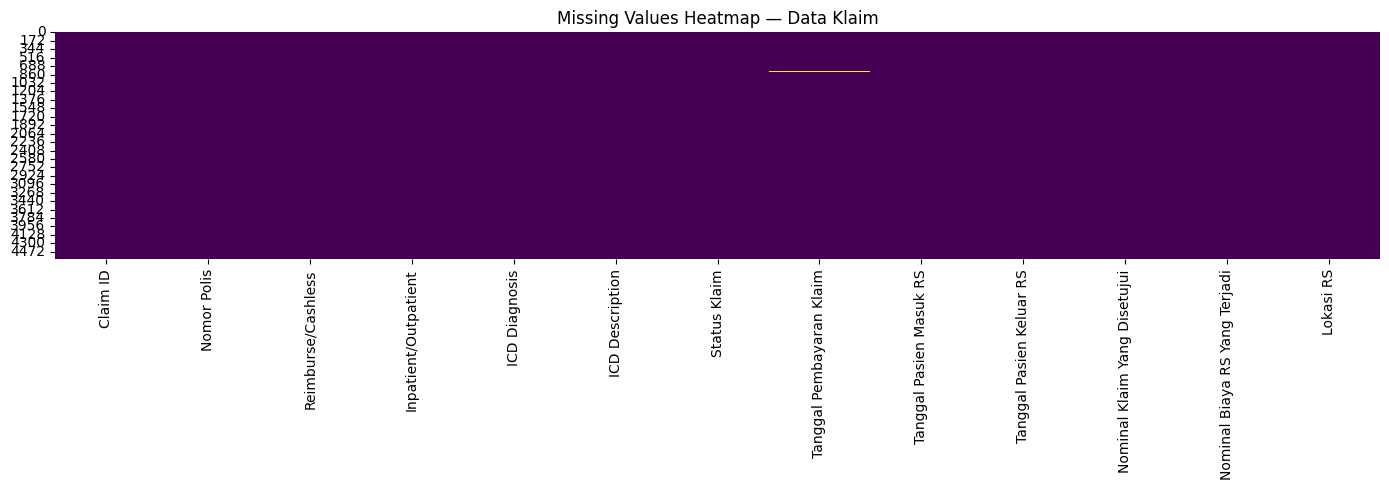


Duplikat dihapus: 0 rows
Baris drop karena Tanggal Masuk RS kosong: 0

Shape polis          : (4096, 6)
Shape klaim (all)    : (4627, 13)
Shape klaim (PAID)   : (4627, 14)

Rentang periode klaim:
Min: 2024-01-01 00:00:00
Max: 2025-07-01 00:00:00


In [3]:
# ── PARSE TANGGAL POLIS ────────────────────────────────
df_polis['Tanggal Lahir'] = pd.to_datetime(
    df_polis['Tanggal Lahir'], format='%Y%m%d'
)
df_polis['Tanggal Efektif Polis'] = pd.to_datetime(
    df_polis['Tanggal Efektif Polis'], format='%Y%m%d'
)

# ── PARSE TANGGAL KLAIM ────────────────────────────────
df_klaim['Tanggal Pembayaran Klaim'] = pd.to_datetime(
    df_klaim['Tanggal Pembayaran Klaim'], errors='coerce'
)
df_klaim['Tanggal Pasien Masuk RS'] = pd.to_datetime(
    df_klaim['Tanggal Pasien Masuk RS'], errors='coerce'
)
df_klaim['Tanggal Pasien Keluar RS'] = pd.to_datetime(
    df_klaim['Tanggal Pasien Keluar RS'], errors='coerce'
)

# ── STRIP WHITESPACE KOLOM STRING ─────────────────────
str_cols_klaim = [
    'Nomor Polis', 'Status Klaim', 'Reimburse/Cashless',
    'Inpatient/Outpatient', 'Lokasi RS', 'ICD Diagnosis', 'ICD Description'
]
for col in str_cols_klaim:
    if col in df_klaim.columns:
        df_klaim[col] = df_klaim[col].str.strip()

df_polis['Nomor Polis'] = df_polis['Nomor Polis'].str.strip()
df_polis['Gender']      = df_polis['Gender'].str.strip()
df_polis['Plan Code']   = df_polis['Plan Code'].str.strip()
df_polis['Domisili']    = df_polis['Domisili'].str.strip()

# ── MISSING VALUE CHECK DATA POLIS ────────────────────
print("=" * 50)
print("MISSING VALUES — DATA POLIS")
print("=" * 50)
mv_polis = df_polis.isnull().sum()
if mv_polis.sum() == 0:
    print("Tidak ada missing value")
else:
    print(mv_polis[mv_polis > 0])

plt.figure(figsize=(10, 4))
sns.heatmap(df_polis.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap — Data Polis')
plt.tight_layout()
plt.show()

# ── MISSING VALUE CHECK DATA KLAIM ────────────────────
print("\n" + "=" * 50)
print("MISSING VALUES — DATA KLAIM")
print("=" * 50)
mv_klaim = df_klaim.isnull().sum()
if mv_klaim.sum() == 0:
    print("Tidak ada missing value")
else:
    print(mv_klaim[mv_klaim > 0])

plt.figure(figsize=(14, 5))
sns.heatmap(df_klaim.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap — Data Klaim')
plt.tight_layout()
plt.show()

# ── HANDLING MISSING VALUES ────────────────────────────
# Inpatient/Outpatient — isi dengan modus
if 'Inpatient/Outpatient' in df_klaim.columns:
    modus_inout = df_klaim['Inpatient/Outpatient'].mode()[0]
    df_klaim['Inpatient/Outpatient'] = df_klaim[
        'Inpatient/Outpatient'
    ].fillna(modus_inout)

# ICD Diagnosis & Description — isi dengan 'UNKNOWN'
df_klaim['ICD Diagnosis']   = df_klaim['ICD Diagnosis'].fillna('UNKNOWN')
df_klaim['ICD Description'] = df_klaim['ICD Description'].fillna('UNKNOWN')

# Lokasi RS — isi dengan 'UNKNOWN'
df_klaim['Lokasi RS'] = df_klaim['Lokasi RS'].fillna('UNKNOWN')

# Tanggal Pembayaran Klaim — biarkan NaN
# karena ada klaim PAID tanpa tanggal bayar (akan difilter nanti)

# ── DROP DUPLIKAT ──────────────────────────────────────
before = df_klaim.shape[0]
df_klaim = df_klaim.drop_duplicates(subset='Claim ID')
print(f"\nDuplikat dihapus: {before - df_klaim.shape[0]} rows")

# ── FILTER STATUS PAID ─────────────────────────────────
df_klaim_paid = df_klaim[df_klaim['Status Klaim'] == 'PAID'].copy()

# Gunakan Tanggal Pasien Masuk RS sebagai acuan periode
df_klaim_paid['Periode_Klaim'] = (
    df_klaim_paid['Tanggal Pasien Masuk RS']
    .dt.to_period('M')
    .dt.to_timestamp()
)

# Drop baris yang Tanggal Pasien Masuk RS-nya NaT
before = df_klaim_paid.shape[0]
df_klaim_paid = df_klaim_paid.dropna(subset=['Tanggal Pasien Masuk RS'])
print(f"Baris drop karena Tanggal Masuk RS kosong: {before - df_klaim_paid.shape[0]}")

print(f"\nShape polis          : {df_polis.shape}")
print(f"Shape klaim (all)    : {df_klaim.shape}")
print(f"Shape klaim (PAID)   : {df_klaim_paid.shape}")
print(f"\nRentang periode klaim:")
print(f"Min: {df_klaim_paid['Periode_Klaim'].min()}")
print(f"Max: {df_klaim_paid['Periode_Klaim'].max()}")

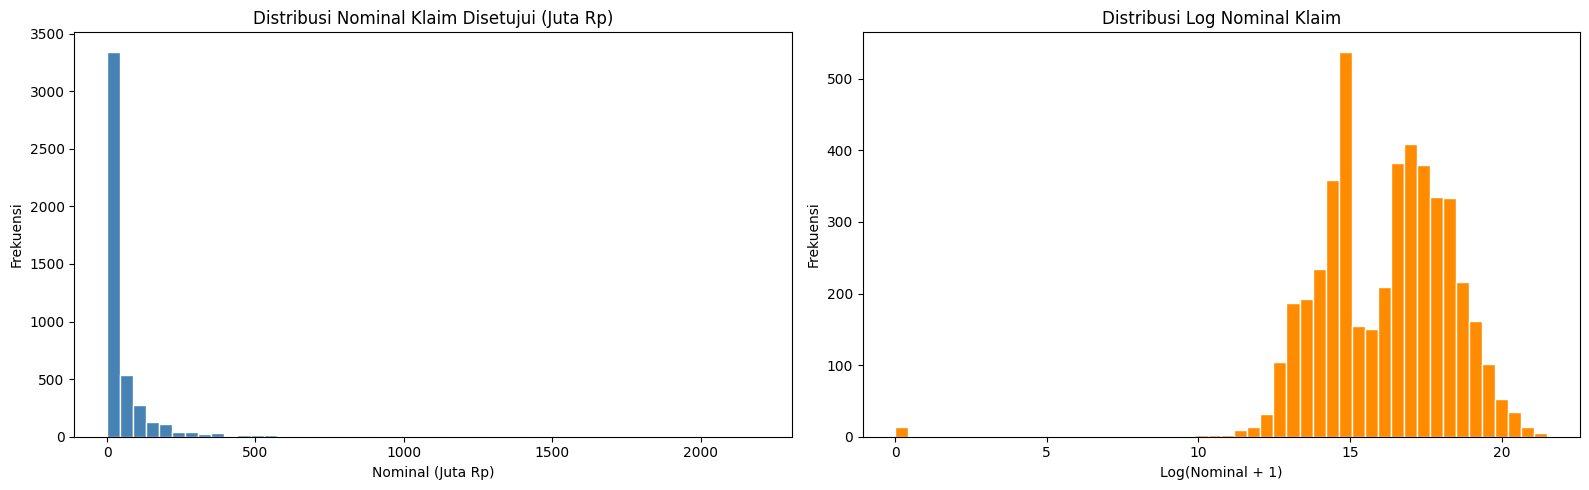

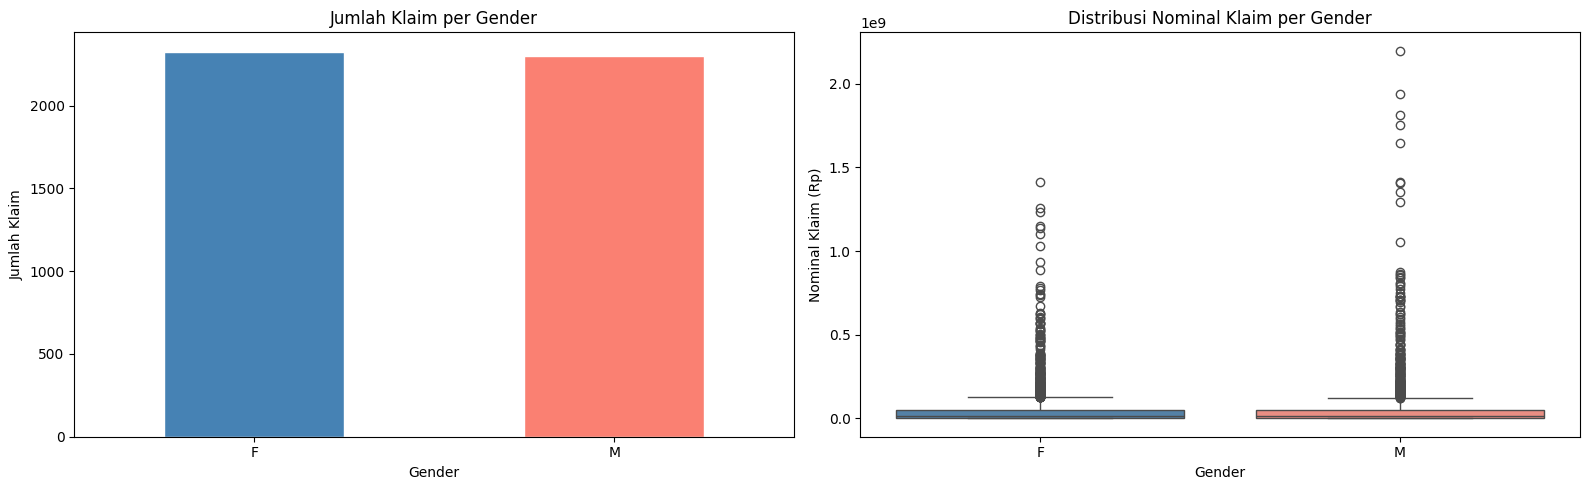

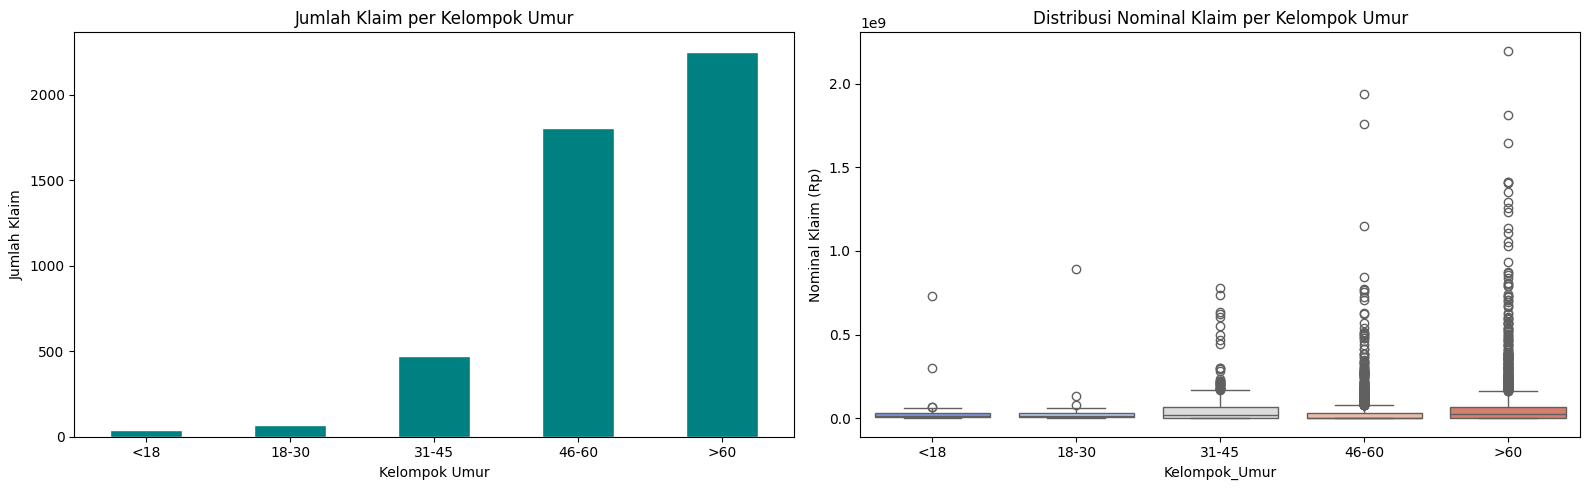

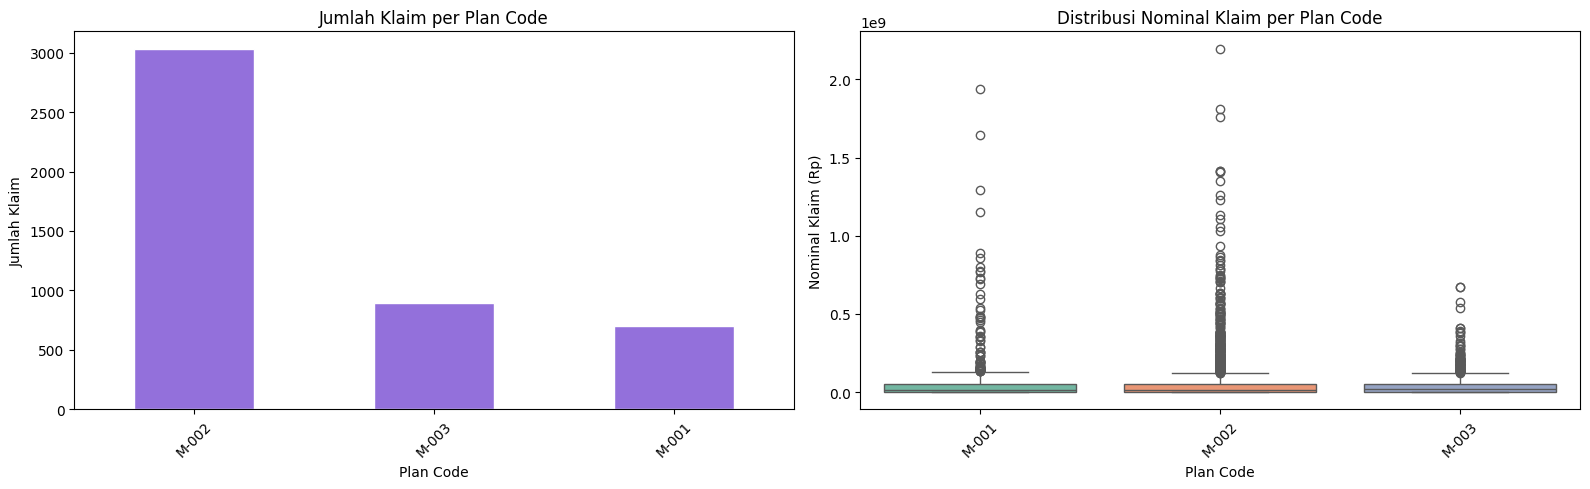

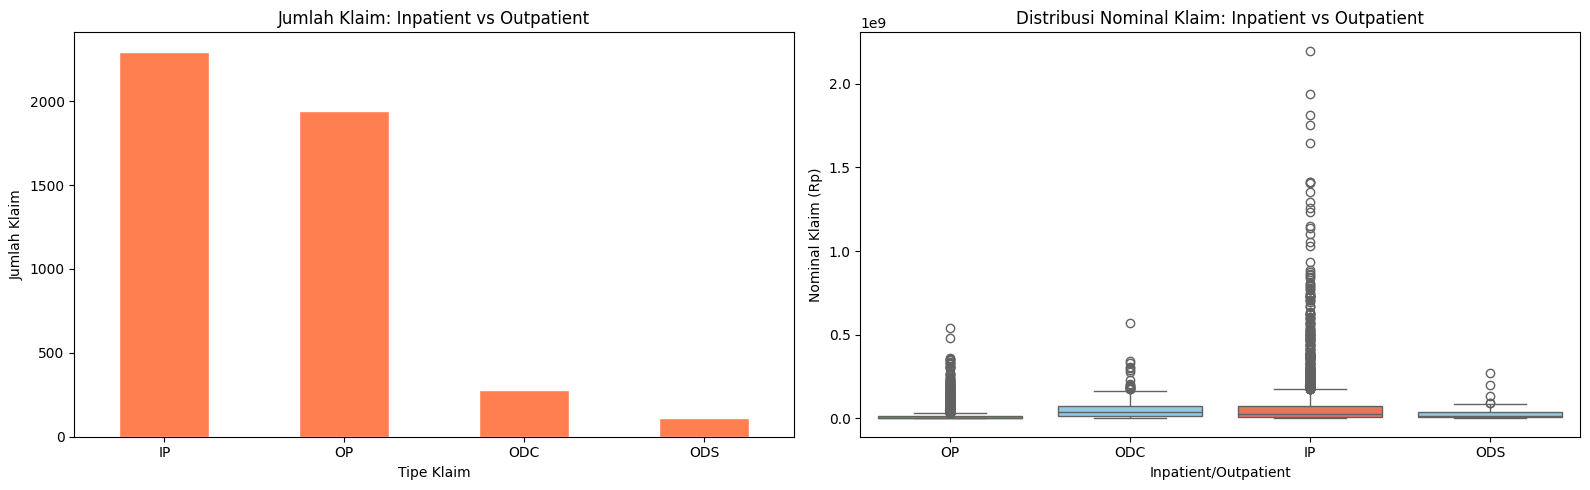

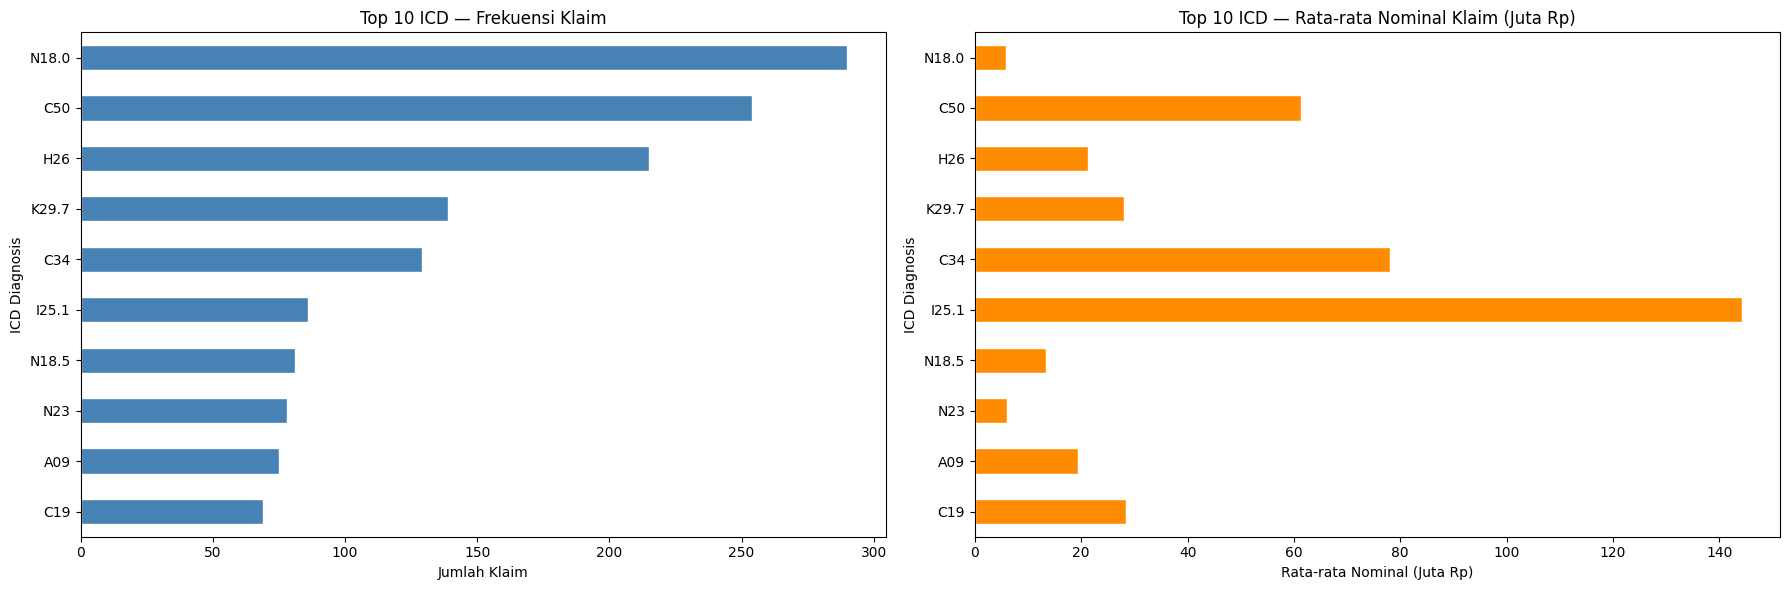

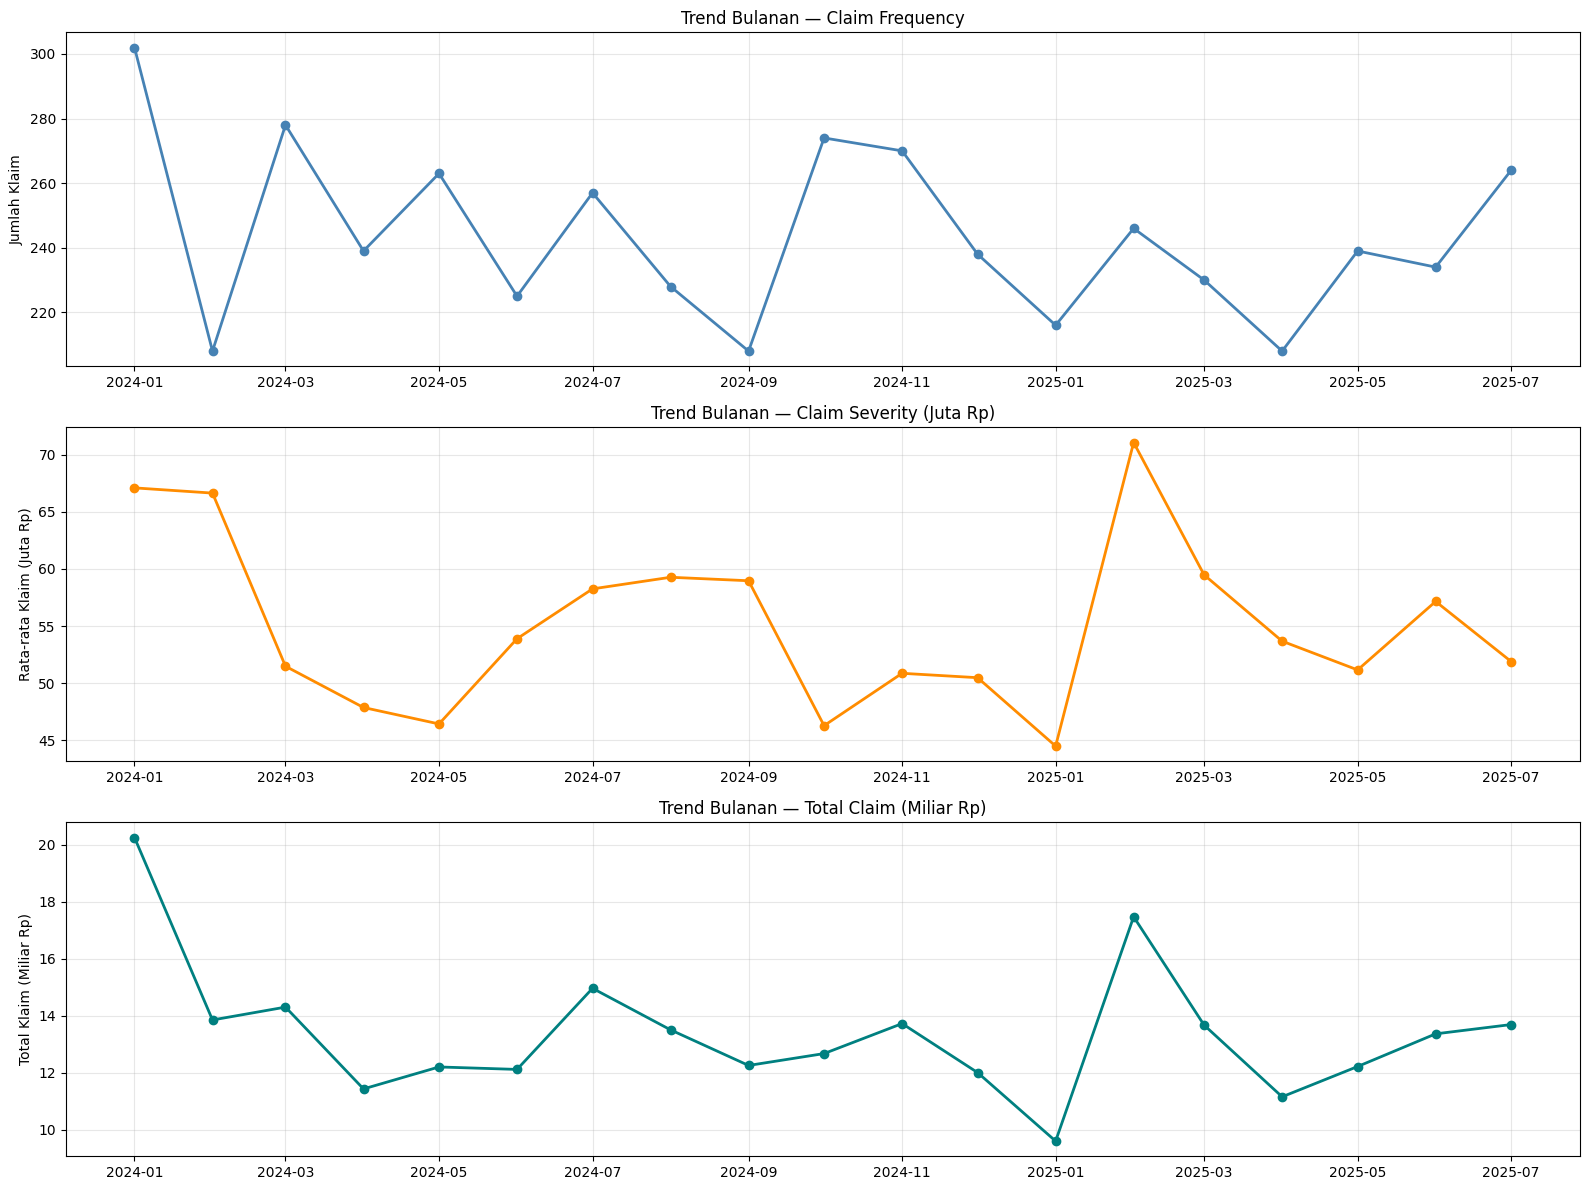

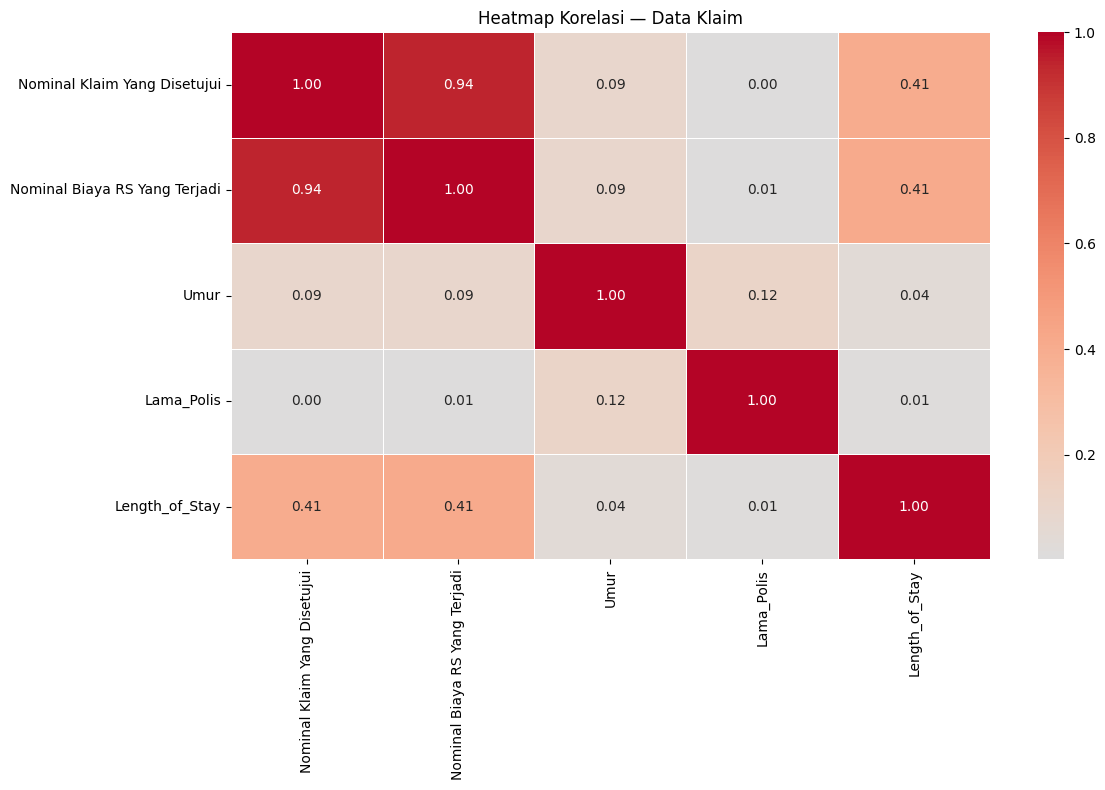

Cell 4 selesai — lanjut Cell 5


In [4]:
# ── FEATURE ENGINEERING POLIS UNTUK EDA ───────────────
reference_date = pd.Timestamp('2025-07-01')

df_polis['Umur'] = (
    (reference_date - df_polis['Tanggal Lahir']).dt.days / 365.25
).astype(int)

df_polis['Lama_Polis'] = (
    (reference_date - df_polis['Tanggal Efektif Polis']).dt.days / 365.25
).round(2)

df_polis['Kelompok_Umur'] = pd.cut(
    df_polis['Umur'],
    bins=[0, 17, 30, 45, 60, 100],
    labels=['<18', '18-30', '31-45', '46-60', '>60']
)

# ── MERGE POLIS KE KLAIM UNTUK EDA ────────────────────
df_merged = df_klaim_paid.merge(
    df_polis[['Nomor Polis', 'Gender', 'Plan Code',
              'Umur', 'Lama_Polis', 'Kelompok_Umur']],
    on='Nomor Polis',
    how='left'
)

df_merged['Length_of_Stay'] = (
    df_merged['Tanggal Pasien Keluar RS'] -
    df_merged['Tanggal Pasien Masuk RS']
).dt.days.clip(lower=0)

# ── 1. DISTRIBUSI NOMINAL KLAIM ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(
    df_merged['Nominal Klaim Yang Disetujui'] / 1e6,
    bins=50, color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribusi Nominal Klaim Disetujui (Juta Rp)')
axes[0].set_xlabel('Nominal (Juta Rp)')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(
    np.log1p(df_merged['Nominal Klaim Yang Disetujui']),
    bins=50, color='darkorange', edgecolor='white'
)
axes[1].set_title('Distribusi Log Nominal Klaim')
axes[1].set_xlabel('Log(Nominal + 1)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# ── 2. KLAIM PER GENDER ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_merged['Gender'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'salmon'], edgecolor='white'
)
axes[0].set_title('Jumlah Klaim per Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(
    data=df_merged, x='Gender',
    y='Nominal Klaim Yang Disetujui',
    ax=axes[1], palette=['steelblue', 'salmon']
)
axes[1].set_title('Distribusi Nominal Klaim per Gender')
axes[1].set_ylabel('Nominal Klaim (Rp)')

plt.tight_layout()
plt.show()

# ── 3. KLAIM PER KELOMPOK UMUR ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_merged['Kelompok_Umur'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='teal', edgecolor='white'
)
axes[0].set_title('Jumlah Klaim per Kelompok Umur')
axes[0].set_xlabel('Kelompok Umur')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(
    data=df_merged, x='Kelompok_Umur',
    y='Nominal Klaim Yang Disetujui',
    ax=axes[1], palette='coolwarm',
    order=['<18', '18-30', '31-45', '46-60', '>60']
)
axes[1].set_title('Distribusi Nominal Klaim per Kelompok Umur')
axes[1].set_ylabel('Nominal Klaim (Rp)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# ── 4. KLAIM PER PLAN CODE ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_merged['Plan Code'].value_counts().plot(
    kind='bar', ax=axes[0],
    color='mediumpurple', edgecolor='white'
)
axes[0].set_title('Jumlah Klaim per Plan Code')
axes[0].set_xlabel('Plan Code')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(
    data=df_merged, x='Plan Code',
    y='Nominal Klaim Yang Disetujui',
    ax=axes[1], palette='Set2'
)
axes[1].set_title('Distribusi Nominal Klaim per Plan Code')
axes[1].set_ylabel('Nominal Klaim (Rp)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ── 5. INPATIENT VS OUTPATIENT ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_merged['Inpatient/Outpatient'].value_counts().plot(
    kind='bar', ax=axes[0], color='coral', edgecolor='white'
)
axes[0].set_title('Jumlah Klaim: Inpatient vs Outpatient')
axes[0].set_xlabel('Tipe Klaim')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(
    data=df_merged, x='Inpatient/Outpatient',
    y='Nominal Klaim Yang Disetujui',
    ax=axes[1], palette=['tomato', 'skyblue']
)
axes[1].set_title('Distribusi Nominal Klaim: Inpatient vs Outpatient')
axes[1].set_ylabel('Nominal Klaim (Rp)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# ── 6. TOP 10 ICD DIAGNOSIS ────────────────────────────
top_icd = (
    df_merged.groupby('ICD Diagnosis')['Nominal Klaim Yang Disetujui']
    .agg(['count', 'mean'])
    .sort_values('count', ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_icd['count'].plot(
    kind='barh', ax=axes[0],
    color='steelblue', edgecolor='white'
)
axes[0].set_title('Top 10 ICD — Frekuensi Klaim')
axes[0].set_xlabel('Jumlah Klaim')
axes[0].invert_yaxis()

top_icd['mean'].div(1e6).plot(
    kind='barh', ax=axes[1],
    color='darkorange', edgecolor='white'
)
axes[1].set_title('Top 10 ICD — Rata-rata Nominal Klaim (Juta Rp)')
axes[1].set_xlabel('Rata-rata Nominal (Juta Rp)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# ── 7. TREND BULANAN ───────────────────────────────────
monthly_trend = df_klaim_paid.groupby('Periode_Klaim').agg(
    Claim_Frequency=('Claim ID', 'count'),
    Total_Claim=('Nominal Klaim Yang Disetujui', 'sum')
).reset_index()
monthly_trend['Claim_Severity'] = (
    monthly_trend['Total_Claim'] / monthly_trend['Claim_Frequency']
)

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(
    monthly_trend['Periode_Klaim'],
    monthly_trend['Claim_Frequency'],
    marker='o', color='steelblue', linewidth=2
)
axes[0].set_title('Trend Bulanan — Claim Frequency')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    monthly_trend['Periode_Klaim'],
    monthly_trend['Claim_Severity'] / 1e6,
    marker='o', color='darkorange', linewidth=2
)
axes[1].set_title('Trend Bulanan — Claim Severity (Juta Rp)')
axes[1].set_ylabel('Rata-rata Klaim (Juta Rp)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(
    monthly_trend['Periode_Klaim'],
    monthly_trend['Total_Claim'] / 1e9,
    marker='o', color='teal', linewidth=2
)
axes[2].set_title('Trend Bulanan — Total Claim (Miliar Rp)')
axes[2].set_ylabel('Total Klaim (Miliar Rp)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 8. HEATMAP KORELASI ────────────────────────────────
numeric_cols = df_merged.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_cols.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Heatmap Korelasi — Data Klaim')
plt.tight_layout()
plt.show()

print("Cell 4 selesai — lanjut Cell 5")

In [5]:
# ── AGREGASI BULANAN ───────────────────────────────────
df_monthly = df_klaim_paid.groupby('Periode_Klaim').agg(
    Claim_Frequency=('Claim ID', 'count'),
    Total_Claim=('Nominal Klaim Yang Disetujui', 'sum'),
    Claim_Severity=('Nominal Klaim Yang Disetujui', 'mean')
).reset_index()

df_monthly = df_monthly.sort_values('Periode_Klaim').reset_index(drop=True)

# ── EXPOSURE PER BULAN ─────────────────────────────────
periods = df_monthly['Periode_Klaim'].unique()

exposure_list = []
for period in periods:
    period_end = period + pd.offsets.MonthEnd(0)
    n_active   = df_polis[
        df_polis['Tanggal Efektif Polis'] <= period_end
    ].shape[0]
    exposure_list.append({
        'Periode_Klaim': period,
        'Exposure'     : n_active
    })

df_exposure = pd.DataFrame(exposure_list)
df_monthly  = df_monthly.merge(df_exposure, on='Periode_Klaim', how='left')

# ── WINSORIZE ──────────────────────────────────────────
df_monthly['Claim_Severity_wins'] = winsorize(
    df_monthly['Claim_Severity'], limits=[0.05, 0.05]
)
df_monthly['Total_Claim_wins'] = winsorize(
    df_monthly['Total_Claim'], limits=[0.05, 0.05]
)

# ── TIME & CALENDAR FEATURES ───────────────────────────
df_monthly['Time_Index'] = np.arange(len(df_monthly))
df_monthly['Month']      = df_monthly['Periode_Klaim'].dt.month
df_monthly['Quarter']    = df_monthly['Periode_Klaim'].dt.quarter

# ── CLAIM RATE ─────────────────────────────────────────
df_monthly['Claim_Rate'] = (
    df_monthly['Claim_Frequency'] / df_monthly['Exposure']
)

# ── LAG FEATURES — FREQUENCY ───────────────────────────
df_monthly['Freq_Lag_1']  = df_monthly['Claim_Frequency'].shift(1)
df_monthly['Freq_Lag_2']  = df_monthly['Claim_Frequency'].shift(2)
df_monthly['Freq_Lag_12'] = df_monthly['Claim_Frequency'].shift(12)

# ── LAG FEATURES — SEVERITY ────────────────────────────
df_monthly['Sev_Lag_1'] = df_monthly['Claim_Severity_wins'].shift(1)
df_monthly['Sev_Lag_2'] = df_monthly['Claim_Severity_wins'].shift(2)

# ── LAG FEATURES — TOTAL ───────────────────────────────
df_monthly['Total_Lag_1'] = df_monthly['Total_Claim_wins'].shift(1)
df_monthly['Total_Lag_2'] = df_monthly['Total_Claim_wins'].shift(2)

# ── LAG FEATURES — CLAIM RATE ──────────────────────────
df_monthly['Rate_Lag_1'] = df_monthly['Claim_Rate'].shift(1)
df_monthly['Rate_Lag_2'] = df_monthly['Claim_Rate'].shift(2)

# ── ROLLING MEAN 3 BULAN ───────────────────────────────
df_monthly['Freq_Rolling_3']  = (
    df_monthly['Claim_Frequency'].shift(1).rolling(3).mean()
)
df_monthly['Sev_Rolling_3']   = (
    df_monthly['Claim_Severity_wins'].shift(1).rolling(3).mean()
)
df_monthly['Total_Rolling_3'] = (
    df_monthly['Total_Claim_wins'].shift(1).rolling(3).mean()
)

# ── ROLLING STD 3 BULAN ────────────────────────────────
df_monthly['Freq_Rolling_std3'] = (
    df_monthly['Claim_Frequency'].shift(1).rolling(3).std()
)
df_monthly['Sev_Rolling_std3']  = (
    df_monthly['Claim_Severity_wins'].shift(1).rolling(3).std()
)

# ── MOM GROWTH RATE ────────────────────────────────────
df_monthly['Freq_MoM'] = df_monthly['Claim_Frequency'].pct_change(1)
df_monthly['Sev_MoM']  = df_monthly['Claim_Severity_wins'].pct_change(1)

# ── FILL NaN LAG & ROLLING DENGAN 0 ───────────────────
lag_roll_cols = [
    c for c in df_monthly.columns
    if any(x in c for x in ['Lag', 'Rolling', 'MoM'])
]
df_monthly[lag_roll_cols] = df_monthly[lag_roll_cols].fillna(0)

# ── SUMMARY ───────────────────────────────────────────
print("=" * 50)
print("DATA BULANAN — SUMMARY")
print("=" * 50)
print(f"Shape          : {df_monthly.shape}")
print(f"Periode        : {df_monthly['Periode_Klaim'].min()} "
      f"s/d {df_monthly['Periode_Klaim'].max()}")
print(f"Total observasi: {len(df_monthly)} bulan")
print(f"\nKolom tersedia :")
print(df_monthly.columns.tolist())
display(df_monthly.head(10))

# ── MISSING VALUE CHECK MONTHLY ────────────────────────
print("\n" + "=" * 50)
print("MISSING VALUES — DATA BULANAN")
print("=" * 50)
mv_monthly = df_monthly.isnull().sum()
if mv_monthly.sum() == 0:
    print("Tidak ada missing value")
else:
    print(mv_monthly[mv_monthly > 0])

# ── DEFINE FEATURE SETS ────────────────────────────────
FEATURES_FREQ = [
    'Time_Index', 'Month', 'Quarter',
    'Freq_Lag_1', 'Freq_Lag_2',
    'Freq_Rolling_3', 'Freq_Rolling_std3',
    'Freq_MoM', 'Rate_Lag_1', 'Exposure'
]

FEATURES_SEV = [
    'Time_Index', 'Month', 'Quarter',
    'Sev_Lag_1', 'Sev_Lag_2',
    'Sev_Rolling_3', 'Sev_Rolling_std3',
    'Sev_MoM', 'Freq_Lag_1', 'Exposure'
]

FEATURES_TOTAL = [
    'Time_Index', 'Month', 'Quarter',
    'Total_Lag_1', 'Total_Lag_2',
    'Total_Rolling_3',
    'Freq_Lag_1', 'Sev_Lag_1',
    'Freq_Rolling_3', 'Sev_Rolling_3', 'Exposure'
]

print("\n" + "=" * 50)
print("FEATURE SETS")
print("=" * 50)
print(f"Freq  : {len(FEATURES_FREQ)} fitur  -> {FEATURES_FREQ}")
print(f"Sev   : {len(FEATURES_SEV)} fitur  -> {FEATURES_SEV}")
print(f"Total : {len(FEATURES_TOTAL)} fitur -> {FEATURES_TOTAL}")

print("\nCell 5 selesai — lanjut Cell 6")

DATA BULANAN — SUMMARY
Shape          : (19, 27)
Periode        : 2024-01-01 00:00:00 s/d 2025-07-01 00:00:00
Total observasi: 19 bulan

Kolom tersedia :
['Periode_Klaim', 'Claim_Frequency', 'Total_Claim', 'Claim_Severity', 'Exposure', 'Claim_Severity_wins', 'Total_Claim_wins', 'Time_Index', 'Month', 'Quarter', 'Claim_Rate', 'Freq_Lag_1', 'Freq_Lag_2', 'Freq_Lag_12', 'Sev_Lag_1', 'Sev_Lag_2', 'Total_Lag_1', 'Total_Lag_2', 'Rate_Lag_1', 'Rate_Lag_2', 'Freq_Rolling_3', 'Sev_Rolling_3', 'Total_Rolling_3', 'Freq_Rolling_std3', 'Sev_Rolling_std3', 'Freq_MoM', 'Sev_MoM']


,Periode_Klaim,Claim_Frequency,Total_Claim,Claim_Severity,Exposure,Claim_Severity_wins,Total_Claim_wins,Time_Index,Month,Quarter,...,Total_Lag_2,Rate_Lag_1,Rate_Lag_2,Freq_Rolling_3,Sev_Rolling_3,Total_Rolling_3,Freq_Rolling_std3,Sev_Rolling_std3,Freq_MoM,Sev_MoM
0,2024-01-01,302,2.026098e+10,6.708934e+07,4096,6.708934e+07,2.026098e+10,0,1,1,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
1,2024-02-01,208,1.385965e+10,6.663291e+07,4096,6.663291e+07,1.385965e+10,1,2,1,...,0.000000e+00,0.073730,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,-0.311258,-0.006803
2,2024-03-01,278,1.431126e+10,5.147935e+07,4096,5.147935e+07,1.431126e+10,2,3,1,...,2.026098e+10,0.050781,0.073730,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.336538,-0.227419
3,2024-04-01,239,1.144106e+10,4.787056e+07,4096,4.787056e+07,1.144106e+10,3,4,2,...,1.385965e+10,0.067871,0.050781,262.666667,6.173387e+07,1.614396e+10,48.839874,8.883607e+06,-0.140288,-0.070102
4,2024-05-01,263,1.221146e+10,4.643141e+07,4096,4.643141e+07,1.221146e+10,4,5,2,...,1.431126e+10,0.058350,0.067871,241.666667,5.532760e+07,1.320399e+10,35.076108,9.955567e+06,0.100418,-0.030063
5,2024-06-01,225,1.212517e+10,5.388963e+07,4096,5.388963e+07,1.212517e+10,5,6,2,...,1.144106e+10,0.064209,0.058350,260.000000,4.859377e+07,1.265459e+10,19.672316,2.600516e+06,-0.144487,0.160629
6,2024-07-01,257,1.497052e+10,5.825104e+07,4096,5.825104e+07,1.497052e+10,6,7,3,...,1.221146e+10,0.054932,0.064209,242.333333,4.939720e+07,1.192590e+10,19.218047,3.956544e+06,0.142222,0.080932
7,2024-08-01,228,1.351294e+10,5.926726e+07,4096,5.926726e+07,1.351294e+10,7,8,3,...,1.212517e+10,0.062744,0.054932,248.333333,5.285736e+07,1.310238e+10,20.428738,5.977045e+06,-0.112840,0.017446
8,2024-09-01,208,1.226412e+10,5.896211e+07,4096,5.896211e+07,1.226412e+10,8,9,3,...,1.497052e+10,0.055664,0.062744,236.666667,5.713598e+07,1.353621e+10,17.672955,2.856965e+06,-0.087719,-0.005149
9,2024-10-01,274,1.268117e+10,4.628163e+07,4096,4.628163e+07,1.268117e+10,9,10,4,...,1.351294e+10,0.050781,0.055664,231.000000,5.882680e+07,1.358252e+10,24.637370,5.214491e+05,0.317308,-0.215062



MISSING VALUES — DATA BULANAN
Tidak ada missing value

FEATURE SETS
Freq  : 10 fitur  -> ['Time_Index', 'Month', 'Quarter', 'Freq_Lag_1', 'Freq_Lag_2', 'Freq_Rolling_3', 'Freq_Rolling_std3', 'Freq_MoM', 'Rate_Lag_1', 'Exposure']
Sev   : 10 fitur  -> ['Time_Index', 'Month', 'Quarter', 'Sev_Lag_1', 'Sev_Lag_2', 'Sev_Rolling_3', 'Sev_Rolling_std3', 'Sev_MoM', 'Freq_Lag_1', 'Exposure']
Total : 11 fitur -> ['Time_Index', 'Month', 'Quarter', 'Total_Lag_1', 'Total_Lag_2', 'Total_Rolling_3', 'Freq_Lag_1', 'Sev_Lag_1', 'Freq_Rolling_3', 'Sev_Rolling_3', 'Exposure']

Cell 5 selesai — lanjut Cell 6


In [6]:
# ── WALK-FORWARD SPLITS ────────────────────────────────
def walk_forward_splits(df, min_train_size=14):
    splits = []
    n      = len(df)
    for val_idx in range(min_train_size, n):
        train = df.iloc[:val_idx].copy()
        val   = df.iloc[val_idx:val_idx + 1].copy()
        splits.append((train, val))
    return splits

splits = walk_forward_splits(df_monthly, min_train_size=14)

print("=" * 50)
print("WALK-FORWARD SPLITS")
print("=" * 50)
print(f"Jumlah fold: {len(splits)}")
for i, (tr, vl) in enumerate(splits):
    print(
        f"Fold {i+1} | "
        f"Train: {tr['Periode_Klaim'].min().strftime('%Y-%m')} "
        f"s/d {tr['Periode_Klaim'].max().strftime('%Y-%m')} "
        f"({len(tr)} bulan) | "
        f"Val: {vl['Periode_Klaim'].iloc[0].strftime('%Y-%m')}"
    )

# ── HELPER: SAFE MAPE ──────────────────────────────────
def safe_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask   = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100

# ── HELPER: RUN PROPHET ────────────────────────────────
def run_prophet(train_df, target_col, periods=1, freq='MS'):
    prophet_df = train_df[['Periode_Klaim', target_col]].rename(
        columns={'Periode_Klaim': 'ds', target_col: 'y'}
    )
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=5.0,
        interval_width=0.95
    )
    model.fit(prophet_df)
    future   = model.make_future_dataframe(periods=periods, freq=freq)
    forecast = model.predict(future)
    pred     = forecast['yhat'].iloc[-periods:].values
    return pred

# ── HELPER: RUN LIGHTGBM ───────────────────────────────
def run_lgbm(train_df, val_df, features, target_col):
    X_train = train_df[features]
    y_train = train_df[target_col]
    X_val   = val_df[features]

    model = LGBMRegressor(
        n_estimators=200,
        max_depth=2,
        num_leaves=4,
        min_child_samples=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_val)[0]
    return pred, model

# ── HELPER: ENSEMBLE MAPE ──────────────────────────────
def ensemble_mape(weight_prophet, actuals, prophet_preds, lgbm_preds):
    weight_lgbm = 1 - weight_prophet
    ensemble    = (
        weight_prophet * np.array(prophet_preds) +
        weight_lgbm    * np.array(lgbm_preds)
    )
    return safe_mape(actuals, ensemble)

# ── HELPER: FIND BEST WEIGHT ───────────────────────────
def find_best_weight(actuals, prophet_preds, lgbm_preds, n_grid=100):
    best_weight = 0.5
    best_mape   = np.inf
    for w in np.linspace(0, 1, n_grid + 1):
        mape = ensemble_mape(w, actuals, prophet_preds, lgbm_preds)
        if mape < best_mape:
            best_mape   = mape
            best_weight = w
    return best_weight, best_mape

# ── HELPER: BUILD FUTURE FEATURES ─────────────────────
def build_future_features(temp_df, next_period, avg_exposure):
    next_tidx    = temp_df['Time_Index'].max() + 1
    next_month   = next_period.month
    next_quarter = (next_month - 1) // 3 + 1

    last        = temp_df.iloc[-1]
    second_last = temp_df.iloc[-2] if len(temp_df) >= 2 else last
    last_3      = temp_df['Claim_Frequency'].iloc[-3:]
    last_3_sev  = temp_df['Claim_Severity_wins'].iloc[-3:]
    last_3_tot  = temp_df['Total_Claim_wins'].iloc[-3:]

    new_feat = {
        'Time_Index'        : next_tidx,
        'Month'             : next_month,
        'Quarter'           : next_quarter,
        'Freq_Lag_1'        : last['Claim_Frequency'],
        'Freq_Lag_2'        : second_last['Claim_Frequency'],
        'Freq_Rolling_3'    : last_3.mean(),
        'Freq_Rolling_std3' : last_3.std() if len(last_3) >= 2 else 0,
        'Freq_MoM'          : (
            (last['Claim_Frequency'] - second_last['Claim_Frequency']) /
            (second_last['Claim_Frequency'] + 1e-9)
        ),
        'Rate_Lag_1'        : last['Claim_Rate'],
        'Rate_Lag_2'        : second_last['Claim_Rate'],
        'Sev_Lag_1'         : last['Claim_Severity_wins'],
        'Sev_Lag_2'         : second_last['Claim_Severity_wins'],
        'Sev_Rolling_3'     : last_3_sev.mean(),
        'Sev_Rolling_std3'  : last_3_sev.std() if len(last_3_sev) >= 2 else 0,
        'Sev_MoM'           : (
            (last['Claim_Severity_wins'] - second_last['Claim_Severity_wins']) /
            (second_last['Claim_Severity_wins'] + 1e-9)
        ),
        'Total_Lag_1'       : last['Total_Claim_wins'],
        'Total_Lag_2'       : second_last['Total_Claim_wins'],
        'Total_Rolling_3'   : last_3_tot.mean(),
        'Exposure'          : avg_exposure,
    }
    return new_feat, next_tidx, next_month, next_quarter

print("\nSemua helper function siap.")
print("Cell 6 selesai — lanjut Cell 7")

WALK-FORWARD SPLITS
Jumlah fold: 5
Fold 1 | Train: 2024-01 s/d 2025-02 (14 bulan) | Val: 2025-03
Fold 2 | Train: 2024-01 s/d 2025-03 (15 bulan) | Val: 2025-04
Fold 3 | Train: 2024-01 s/d 2025-04 (16 bulan) | Val: 2025-05
Fold 4 | Train: 2024-01 s/d 2025-05 (17 bulan) | Val: 2025-06
Fold 5 | Train: 2024-01 s/d 2025-06 (18 bulan) | Val: 2025-07

Semua helper function siap.
Cell 6 selesai — lanjut Cell 7


In [7]:
# ── WALK-FORWARD VALIDATION PROPHET ───────────────────
prophet_freq_preds        = []
prophet_sev_preds         = []
prophet_total_preds       = []
prophet_val_actuals_freq  = []
prophet_val_actuals_sev   = []
prophet_val_actuals_total = []

print("=" * 50)
print("WALK-FORWARD VALIDATION — Prophet")
print("=" * 50)

for i, (train, val) in enumerate(splits):
    p_freq = run_prophet(train, 'Claim_Frequency', periods=1)[0]
    prophet_freq_preds.append(p_freq)
    prophet_val_actuals_freq.append(val['Claim_Frequency'].iloc[0])

    p_sev = run_prophet(train, 'Claim_Severity_wins', periods=1)[0]
    prophet_sev_preds.append(p_sev)
    prophet_val_actuals_sev.append(val['Claim_Severity_wins'].iloc[0])

    p_total = run_prophet(train, 'Total_Claim_wins', periods=1)[0]
    prophet_total_preds.append(p_total)
    prophet_val_actuals_total.append(val['Total_Claim_wins'].iloc[0])

    print(f"Fold {i+1} selesai | "
          f"Val: {val['Periode_Klaim'].iloc[0].strftime('%Y-%m')}")

# Clip negatif
prophet_freq_preds  = np.clip(prophet_freq_preds,  0, None)
prophet_sev_preds   = np.clip(prophet_sev_preds,   0, None)
prophet_total_preds = np.clip(prophet_total_preds, 0, None)

mape_prophet_freq  = safe_mape(prophet_val_actuals_freq,  prophet_freq_preds)
mape_prophet_sev   = safe_mape(prophet_val_actuals_sev,   prophet_sev_preds)
mape_prophet_total = safe_mape(prophet_val_actuals_total, prophet_total_preds)

print("\n" + "=" * 50)
print("PROPHET VALIDATION MAPE")
print("=" * 50)
print(f"Frequency  : {mape_prophet_freq:.2f}%")
print(f"Severity   : {mape_prophet_sev:.2f}%")
print(f"Total Claim: {mape_prophet_total:.2f}%")
print(f"Average    : "
      f"{np.mean([mape_prophet_freq, mape_prophet_sev, mape_prophet_total]):.2f}%")

prophet_val_results = {
    'freq_preds'   : prophet_freq_preds,
    'sev_preds'    : prophet_sev_preds,
    'total_preds'  : prophet_total_preds,
    'actual_freq'  : prophet_val_actuals_freq,
    'actual_sev'   : prophet_val_actuals_sev,
    'actual_total' : prophet_val_actuals_total,
}

# ── WALK-FORWARD VALIDATION LIGHTGBM ──────────────────
lgbm_freq_preds        = []
lgbm_sev_preds         = []
lgbm_total_preds       = []
lgbm_val_actuals_freq  = []
lgbm_val_actuals_sev   = []
lgbm_val_actuals_total = []

print("\n" + "=" * 50)
print("WALK-FORWARD VALIDATION — LightGBM")
print("=" * 50)

for i, (train, val) in enumerate(splits):
    p_freq, _  = run_lgbm(train, val, FEATURES_FREQ,  'Claim_Frequency')
    lgbm_freq_preds.append(p_freq)
    lgbm_val_actuals_freq.append(val['Claim_Frequency'].iloc[0])

    p_sev, _   = run_lgbm(train, val, FEATURES_SEV,   'Claim_Severity_wins')
    lgbm_sev_preds.append(p_sev)
    lgbm_val_actuals_sev.append(val['Claim_Severity_wins'].iloc[0])

    p_total, _ = run_lgbm(train, val, FEATURES_TOTAL, 'Total_Claim_wins')
    lgbm_total_preds.append(p_total)
    lgbm_val_actuals_total.append(val['Total_Claim_wins'].iloc[0])

    print(f"Fold {i+1} selesai | "
          f"Val: {val['Periode_Klaim'].iloc[0].strftime('%Y-%m')}")

# Clip negatif
lgbm_freq_preds  = np.clip(lgbm_freq_preds,  0, None)
lgbm_sev_preds   = np.clip(lgbm_sev_preds,   0, None)
lgbm_total_preds = np.clip(lgbm_total_preds, 0, None)

mape_lgbm_freq  = safe_mape(lgbm_val_actuals_freq,  lgbm_freq_preds)
mape_lgbm_sev   = safe_mape(lgbm_val_actuals_sev,   lgbm_sev_preds)
mape_lgbm_total = safe_mape(lgbm_val_actuals_total, lgbm_total_preds)

print("\n" + "=" * 50)
print("LIGHTGBM VALIDATION MAPE")
print("=" * 50)
print(f"Frequency  : {mape_lgbm_freq:.2f}%")
print(f"Severity   : {mape_lgbm_sev:.2f}%")
print(f"Total Claim: {mape_lgbm_total:.2f}%")
print(f"Average    : "
      f"{np.mean([mape_lgbm_freq, mape_lgbm_sev, mape_lgbm_total]):.2f}%")

lgbm_val_results = {
    'freq_preds'   : lgbm_freq_preds,
    'sev_preds'    : lgbm_sev_preds,
    'total_preds'  : lgbm_total_preds,
    'actual_freq'  : lgbm_val_actuals_freq,
    'actual_sev'   : lgbm_val_actuals_sev,
    'actual_total' : lgbm_val_actuals_total,
}

# ── ENSEMBLE WEIGHT OPTIMIZATION ──────────────────────
print("\n" + "=" * 50)
print("ENSEMBLE WEIGHT OPTIMIZATION")
print("=" * 50)

w_freq,  mape_ens_freq  = find_best_weight(
    prophet_val_results['actual_freq'],
    prophet_val_results['freq_preds'],
    lgbm_val_results['freq_preds']
)
w_sev,   mape_ens_sev   = find_best_weight(
    prophet_val_results['actual_sev'],
    prophet_val_results['sev_preds'],
    lgbm_val_results['sev_preds']
)
w_total, mape_ens_total = find_best_weight(
    prophet_val_results['actual_total'],
    prophet_val_results['total_preds'],
    lgbm_val_results['total_preds']
)

ensemble_weights = {
    'freq' : {'prophet': w_freq,  'lgbm': 1 - w_freq},
    'sev'  : {'prophet': w_sev,   'lgbm': 1 - w_sev},
    'total': {'prophet': w_total, 'lgbm': 1 - w_total},
}

avg_ens_mape = np.mean([mape_ens_freq, mape_ens_sev, mape_ens_total])

# ── TABEL PERBANDINGAN ─────────────────────────────────
print(f"\n{'Target':<12} {'Prophet':>10} {'LightGBM':>10} {'Ensemble':>10}")
print("-" * 45)
print(f"{'Frequency':<12} {mape_prophet_freq:>9.2f}% "
      f"{mape_lgbm_freq:>9.2f}% {mape_ens_freq:>9.2f}%")
print(f"{'Severity':<12} {mape_prophet_sev:>9.2f}% "
      f"{mape_lgbm_sev:>9.2f}% {mape_ens_sev:>9.2f}%")
print(f"{'Total':<12} {mape_prophet_total:>9.2f}% "
      f"{mape_lgbm_total:>9.2f}% {mape_ens_total:>9.2f}%")
print("-" * 45)
print(f"{'Average':<12} "
      f"{np.mean([mape_prophet_freq, mape_prophet_sev, mape_prophet_total]):>9.2f}% "
      f"{np.mean([mape_lgbm_freq, mape_lgbm_sev, mape_lgbm_total]):>9.2f}% "
      f"{avg_ens_mape:>9.2f}%")

print("\n" + "=" * 50)
print("BOBOT OPTIMAL ENSEMBLE")
print("=" * 50)
print(f"Frequency  | Prophet: {w_freq:.2f}  LightGBM: {1-w_freq:.2f} "
      f"| MAPE: {mape_ens_freq:.2f}%")
print(f"Severity   | Prophet: {w_sev:.2f}  LightGBM: {1-w_sev:.2f} "
      f"| MAPE: {mape_ens_sev:.2f}%")
print(f"Total      | Prophet: {w_total:.2f}  LightGBM: {1-w_total:.2f} "
      f"| MAPE: {mape_ens_total:.2f}%")

print("\nCell 7 selesai — lanjut Cell 8")

WALK-FORWARD VALIDATION — Prophet


17:05:20 - cmdstanpy - INFO - Chain [1] start processing
17:05:39 - cmdstanpy - INFO - Chain [1] done processing
17:05:39 - cmdstanpy - INFO - Chain [1] start processing
17:06:00 - cmdstanpy - INFO - Chain [1] done processing
17:06:01 - cmdstanpy - INFO - Chain [1] start processing
17:06:48 - cmdstanpy - INFO - Chain [1] done processing


Fold 1 selesai | Val: 2025-03


17:06:49 - cmdstanpy - INFO - Chain [1] start processing
17:07:03 - cmdstanpy - INFO - Chain [1] done processing
17:07:03 - cmdstanpy - INFO - Chain [1] start processing
17:07:14 - cmdstanpy - INFO - Chain [1] done processing
17:07:15 - cmdstanpy - INFO - Chain [1] start processing
17:07:42 - cmdstanpy - INFO - Chain [1] done processing


Fold 2 selesai | Val: 2025-04


...

Fold 3 selesai | Val: 2025-05


17:09:10 - cmdstanpy - INFO - Chain [1] start processing
17:09:39 - cmdstanpy - INFO - Chain [1] done processing
17:09:39 - cmdstanpy - INFO - Chain [1] start processing
17:10:15 - cmdstanpy - INFO - Chain [1] done processing
17:10:15 - cmdstanpy - INFO - Chain [1] start processing
17:11:21 - cmdstanpy - INFO - Chain [1] done processing


Fold 4 selesai | Val: 2025-06


17:11:22 - cmdstanpy - INFO - Chain [1] start processing
17:12:19 - cmdstanpy - INFO - Chain [1] done processing
17:12:20 - cmdstanpy - INFO - Chain [1] start processing
17:13:03 - cmdstanpy - INFO - Chain [1] done processing
17:13:03 - cmdstanpy - INFO - Chain [1] start processing
17:13:38 - cmdstanpy - INFO - Chain [1] done processing


Fold 5 selesai | Val: 2025-07

PROPHET VALIDATION MAPE
Frequency  : 15.82%
Severity   : 18.70%
Total Claim: 23.52%
Average    : 19.35%

WALK-FORWARD VALIDATION — LightGBM
Fold 1 selesai | Val: 2025-03
Fold 2 selesai | Val: 2025-04
Fold 3 selesai | Val: 2025-05
Fold 4 selesai | Val: 2025-06
Fold 5 selesai | Val: 2025-07

LIGHTGBM VALIDATION MAPE
Frequency  : 9.02%
Severity   : 5.41%
Total Claim: 5.25%
Average    : 6.56%

ENSEMBLE WEIGHT OPTIMIZATION

Target          Prophet   LightGBM   Ensemble
---------------------------------------------
Frequency        15.82%      9.02%      4.69%
Severity         18.70%      5.41%      5.41%
Total            23.52%      5.25%      1.50%
---------------------------------------------
Average          19.35%      6.56%      3.87%

BOBOT OPTIMAL ENSEMBLE
Frequency  | Prophet: 0.22  LightGBM: 0.78 | MAPE: 4.69%
Severity   | Prophet: 0.00  LightGBM: 1.00 | MAPE: 5.41%
Total      | Prophet: 0.16  LightGBM: 0.84 | MAPE: 1.50%

Cell 7 selesai — lanjut Cell

TRAINING PROPHET — Full Data


17:13:45 - cmdstanpy - INFO - Chain [1] start processing
17:14:20 - cmdstanpy - INFO - Chain [1] done processing


Prophet Frequency selesai


17:14:20 - cmdstanpy - INFO - Chain [1] start processing
17:14:31 - cmdstanpy - INFO - Chain [1] done processing


Prophet Severity selesai


17:14:31 - cmdstanpy - INFO - Chain [1] start processing
17:15:28 - cmdstanpy - INFO - Chain [1] done processing


Prophet Total selesai

TRAINING LIGHTGBM — Full Data
LightGBM Frequency selesai
LightGBM Severity selesai
LightGBM Total selesai

IN-SAMPLE MAPE LIGHTGBM (informasi saja)
Frequency  : 1.09%
Severity   : 0.69%
Total Claim: 1.37%
Catatan: in-sample selalu optimistis, gunakan validation MAPE Cell 7 sebagai acuan performa sesungguhnya

FEATURE IMPORTANCE — LightGBM


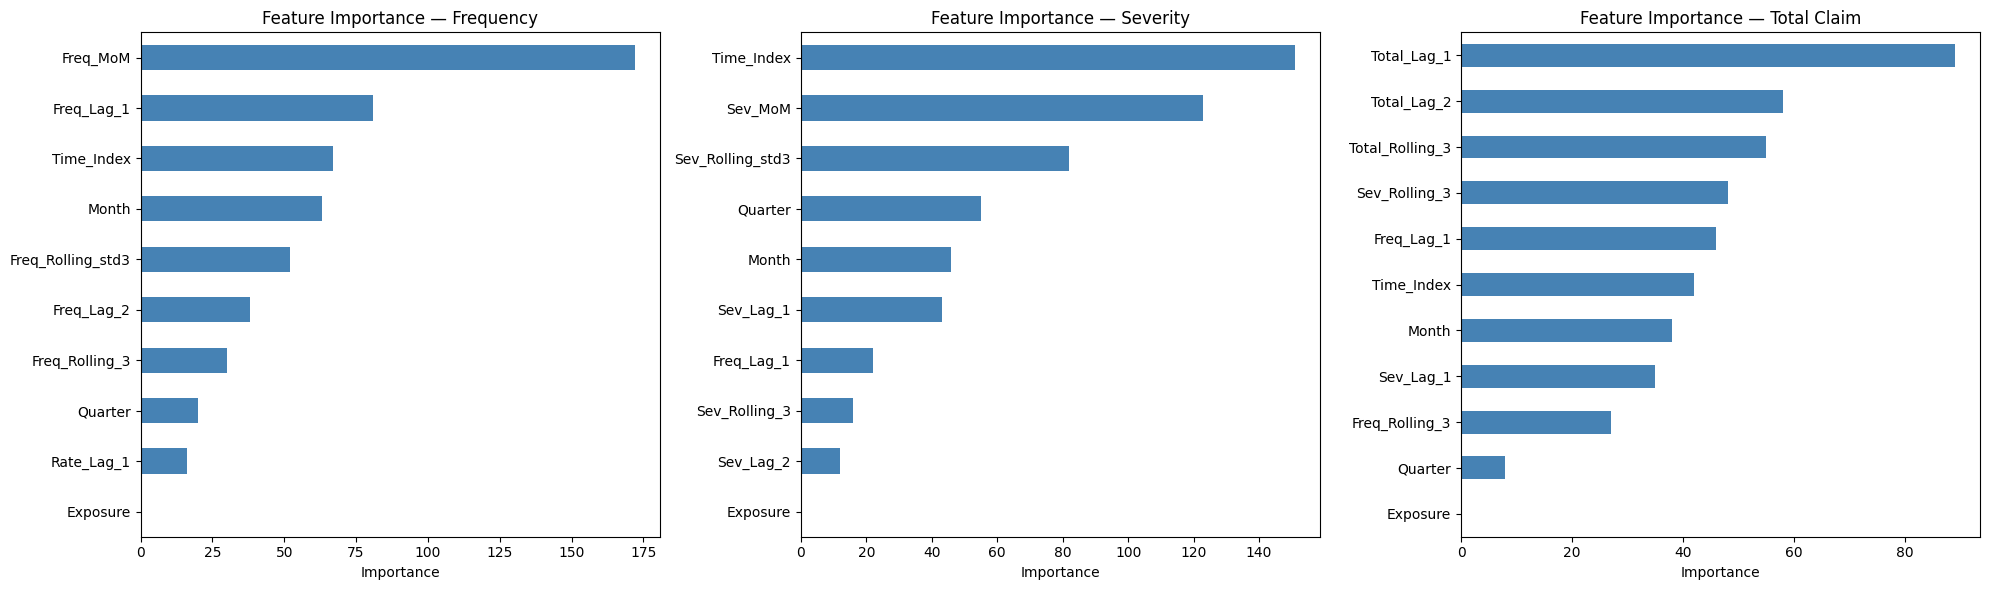


Semua model final siap.
Cell 8 selesai — lanjut Cell 9


In [8]:
# ── PROPHET FINAL MODELS ───────────────────────────────
def fit_prophet_full(df, target_col):
    prophet_df = df[['Periode_Klaim', target_col]].rename(
        columns={'Periode_Klaim': 'ds', target_col: 'y'}
    )
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=5.0,
        interval_width=0.95
    )
    model.fit(prophet_df)
    return model

print("=" * 50)
print("TRAINING PROPHET — Full Data")
print("=" * 50)

full_df = df_monthly.copy()

prophet_model_freq  = fit_prophet_full(full_df, 'Claim_Frequency')
print("Prophet Frequency selesai")

prophet_model_sev   = fit_prophet_full(full_df, 'Claim_Severity_wins')
print("Prophet Severity selesai")

prophet_model_total = fit_prophet_full(full_df, 'Total_Claim_wins')
print("Prophet Total selesai")

# ── LIGHTGBM FINAL MODELS ──────────────────────────────
def fit_lgbm_full(df, features, target_col):
    X = df[features]
    y = df[target_col]
    model = LGBMRegressor(
        n_estimators=200,
        max_depth=2,
        num_leaves=4,
        min_child_samples=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1
    )
    model.fit(X, y)
    return model

print("\n" + "=" * 50)
print("TRAINING LIGHTGBM — Full Data")
print("=" * 50)

lgbm_model_freq  = fit_lgbm_full(full_df, FEATURES_FREQ,  'Claim_Frequency')
print("LightGBM Frequency selesai")

lgbm_model_sev   = fit_lgbm_full(full_df, FEATURES_SEV,   'Claim_Severity_wins')
print("LightGBM Severity selesai")

lgbm_model_total = fit_lgbm_full(full_df, FEATURES_TOTAL, 'Total_Claim_wins')
print("LightGBM Total selesai")

# ── IN-SAMPLE CHECK ────────────────────────────────────
print("\n" + "=" * 50)
print("IN-SAMPLE MAPE LIGHTGBM (informasi saja)")
print("=" * 50)

insample_freq  = lgbm_model_freq.predict(full_df[FEATURES_FREQ])
insample_sev   = lgbm_model_sev.predict(full_df[FEATURES_SEV])
insample_total = lgbm_model_total.predict(full_df[FEATURES_TOTAL])

print(f"Frequency  : {safe_mape(full_df['Claim_Frequency'],    insample_freq):.2f}%")
print(f"Severity   : {safe_mape(full_df['Claim_Severity_wins'], insample_sev):.2f}%")
print(f"Total Claim: {safe_mape(full_df['Total_Claim_wins'],    insample_total):.2f}%")
print("Catatan: in-sample selalu optimistis, "
      "gunakan validation MAPE Cell 7 sebagai acuan performa sesungguhnya")

# ── FEATURE IMPORTANCE ─────────────────────────────────
print("\n" + "=" * 50)
print("FEATURE IMPORTANCE — LightGBM")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (model, features, label) in zip(axes, [
    (lgbm_model_freq,  FEATURES_FREQ,  'Frequency'),
    (lgbm_model_sev,   FEATURES_SEV,   'Severity'),
    (lgbm_model_total, FEATURES_TOTAL, 'Total Claim'),
]):
    imp = pd.Series(model.feature_importances_, index=features)
    imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Feature Importance — {label}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

print("\nSemua model final siap.")
print("Cell 8 selesai — lanjut Cell 9")

In [9]:
# ── FORECAST 5 BULAN KE DEPAN ──────────────────────────
future_steps = 5
temp_df      = full_df.copy()
avg_exposure = full_df['Exposure'].iloc[-3:].mean()

results_freq  = []
results_sev   = []
results_total = []
periods_list  = []

print("=" * 50)
print("FORECAST — Agustus s/d Desember 2025")
print("=" * 50)

for step in range(future_steps):
    next_period = (
        temp_df['Periode_Klaim'].max() + pd.DateOffset(months=1)
    )

    new_feat, next_tidx, next_month, next_quarter = build_future_features(
        temp_df, next_period, avg_exposure
    )

    X_next = pd.DataFrame([new_feat])

    # ── LightGBM prediksi ─────────────────────────────
    p_freq_lgbm  = lgbm_model_freq.predict(X_next[FEATURES_FREQ])[0]
    p_sev_lgbm   = lgbm_model_sev.predict(X_next[FEATURES_SEV])[0]
    p_total_lgbm = lgbm_model_total.predict(X_next[FEATURES_TOTAL])[0]

    # ── Prophet prediksi ──────────────────────────────
    future_prophet      = pd.DataFrame({'ds': [next_period]})
    p_freq_prophet      = prophet_model_freq.predict(future_prophet)['yhat'].iloc[0]
    p_sev_prophet       = prophet_model_sev.predict(future_prophet)['yhat'].iloc[0]
    p_total_prophet     = prophet_model_total.predict(future_prophet)['yhat'].iloc[0]

    # ── Ensemble dengan bobot optimal ─────────────────
    p_freq  = (
        ensemble_weights['freq']['prophet']  * p_freq_prophet +
        ensemble_weights['freq']['lgbm']     * p_freq_lgbm
    )
    p_sev   = (
        ensemble_weights['sev']['prophet']   * p_sev_prophet +
        ensemble_weights['sev']['lgbm']      * p_sev_lgbm
    )
    p_total = (
        ensemble_weights['total']['prophet'] * p_total_prophet +
        ensemble_weights['total']['lgbm']    * p_total_lgbm
    )

    # Safety clip
    p_freq  = max(0, p_freq)
    p_sev   = max(0, p_sev)
    p_total = max(0, p_total)

    results_freq.append(p_freq)
    results_sev.append(p_sev)
    results_total.append(p_total)
    periods_list.append(next_period)

    print(f"  {next_period.strftime('%Y-%m')} | "
          f"Freq: {p_freq:.0f} | "
          f"Sev: Rp {p_sev/1e6:.2f}M | "
          f"Total: Rp {p_total/1e9:.2f}B")

    # ── Update temp_df untuk lag step berikutnya ──────
    new_row = {
        'Periode_Klaim'      : next_period,
        'Claim_Frequency'    : p_freq,
        'Claim_Severity_wins': p_sev,
        'Total_Claim_wins'   : p_total,
        'Claim_Severity'     : p_sev,
        'Total_Claim'        : p_total,
        'Time_Index'         : next_tidx,
        'Month'              : next_month,
        'Quarter'            : next_quarter,
        'Exposure'           : avg_exposure,
        'Claim_Rate'         : p_freq / avg_exposure,
    }
    for col in temp_df.columns:
        if col not in new_row:
            new_row[col] = 0

    temp_df = pd.concat(
        [temp_df, pd.DataFrame([new_row])],
        ignore_index=True
    )

# ── SUSUN HASIL PREDIKSI ───────────────────────────────
df_forecast = pd.DataFrame({
    'Periode'        : periods_list,
    'Claim_Frequency': np.round(results_freq).astype(int),
    'Claim_Severity' : np.round(results_sev),
    'Total_Claim'    : np.round(results_total),
})

print("\n" + "=" * 50)
print("HASIL PREDIKSI AGUSTUS-DESEMBER 2025")
print("=" * 50)
display(df_forecast)

# ── KAGGLE SUBMISSION ──────────────────────────────────
print("\n" + "=" * 50)
print("KAGGLE SUBMISSION")
print("=" * 50)

submission = pd.read_csv('sample_submission.csv')
print("Kolom sample_submission:", submission.columns.tolist())
display(submission.head(10))

for idx, row in df_forecast.iterrows():
    month_str = row['Periode'].strftime('%Y_%m')

    submission.loc[
        submission['id'] == f"{month_str}_Claim_Frequency", 'value'
    ] = row['Claim_Frequency']

    submission.loc[
        submission['id'] == f"{month_str}_Claim_Severity", 'value'
    ] = row['Claim_Severity']

    submission.loc[
        submission['id'] == f"{month_str}_Total_Claim", 'value'
    ] = row['Total_Claim']

# Quality check
print("\n" + "=" * 50)
print("QUALITY CHECK SUBMISSION")
print("=" * 50)
print(f"Total rows    : {len(submission)}")
print(f"Nilai negatif : {(submission['value'] < 0).sum()}")
print(f"Nilai NaN     : {submission['value'].isna().sum()}")
print(f"Nilai nol     : {(submission['value'] == 0).sum()}")

submission.to_csv('submission_final.csv', index=False)
print("\nFile submission_final.csv siap disubmit")
display(submission)

print("\nCell 9 selesai — lanjut Cell 10")

FORECAST — Agustus s/d Desember 2025
  2025-08 | Freq: 240 | Sev: Rp 51.80M | Total: Rp 12.41B
  2025-09 | Freq: 210 | Sev: Rp 56.90M | Total: Rp 11.57B
  2025-10 | Freq: 227 | Sev: Rp 54.72M | Total: Rp 14.46B
  2025-11 | Freq: 252 | Sev: Rp 48.03M | Total: Rp 13.13B
  2025-12 | Freq: 262 | Sev: Rp 49.65M | Total: Rp 11.92B

HASIL PREDIKSI AGUSTUS-DESEMBER 2025


,Periode,Claim_Frequency,Claim_Severity,Total_Claim
0,2025-08-01,240,51803666.0,1.240954e+10
1,2025-09-01,210,56895625.0,1.156990e+10
2,2025-10-01,227,54715425.0,1.445943e+10
3,2025-11-01,252,48034500.0,1.312654e+10
4,2025-12-01,262,49654247.0,1.191528e+10



KAGGLE SUBMISSION
Kolom sample_submission: ['id', 'value']


,id,value
0,2025_08_Claim_Frequency,0
1,2025_08_Claim_Severity,0
2,2025_08_Total_Claim,0
3,2025_09_Claim_Frequency,0
4,2025_09_Claim_Severity,0
5,2025_09_Total_Claim,0
6,2025_10_Claim_Frequency,0
7,2025_10_Claim_Severity,0
8,2025_10_Total_Claim,0
9,2025_11_Claim_Frequency,0



QUALITY CHECK SUBMISSION
Total rows    : 15
Nilai negatif : 0
Nilai NaN     : 0
Nilai nol     : 0

File submission_final.csv siap disubmit


,id,value
0,2025_08_Claim_Frequency,240
1,2025_08_Claim_Severity,51803666
2,2025_08_Total_Claim,12409544388
3,2025_09_Claim_Frequency,210
4,2025_09_Claim_Severity,56895625
5,2025_09_Total_Claim,11569901360
6,2025_10_Claim_Frequency,227
7,2025_10_Claim_Severity,54715425
8,2025_10_Total_Claim,14459430822
9,2025_11_Claim_Frequency,252



Cell 9 selesai — lanjut Cell 10


In [10]:
# ── FORECAST 5 BULAN KE DEPAN ──────────────────────────
future_steps = 5
temp_df      = full_df.copy()
avg_exposure = full_df['Exposure'].iloc[-3:].mean()

results_freq  = []
results_sev   = []
results_total = []
periods_list  = []

print("=" * 50)
print("FORECAST — Agustus s/d Desember 2025")
print("=" * 50)

for step in range(future_steps):
    next_period = (
        temp_df['Periode_Klaim'].max() + pd.DateOffset(months=1)
    )

    # Bangun features
    new_feat, next_tidx, next_month, next_quarter = build_future_features(
        temp_df, next_period, avg_exposure
    )
    X_next = pd.DataFrame([new_feat])

    # ── LightGBM prediksi ──────────────────────────────
    p_freq_lgbm  = lgbm_model_freq.predict(X_next[FEATURES_FREQ])[0]
    p_sev_lgbm   = lgbm_model_sev.predict(X_next[FEATURES_SEV])[0]
    p_total_lgbm = lgbm_model_total.predict(X_next[FEATURES_TOTAL])[0]

    # ── Prophet prediksi ───────────────────────────────
    future_prophet      = pd.DataFrame({'ds': [next_period]})
    p_freq_prophet      = prophet_model_freq.predict(future_prophet)['yhat'].iloc[0]
    p_sev_prophet       = prophet_model_sev.predict(future_prophet)['yhat'].iloc[0]
    p_total_prophet     = prophet_model_total.predict(future_prophet)['yhat'].iloc[0]

    # ── Ensemble dengan bobot optimal ──────────────────
    p_freq  = (
        ensemble_weights['freq']['prophet']  * p_freq_prophet +
        ensemble_weights['freq']['lgbm']     * p_freq_lgbm
    )
    p_sev   = (
        ensemble_weights['sev']['prophet']   * p_sev_prophet +
        ensemble_weights['sev']['lgbm']      * p_sev_lgbm
    )
    p_total = (
        ensemble_weights['total']['prophet'] * p_total_prophet +
        ensemble_weights['total']['lgbm']    * p_total_lgbm
    )

    # Safety clip
    p_freq  = max(0, p_freq)
    p_sev   = max(0, p_sev)
    p_total = max(0, p_total)

    results_freq.append(p_freq)
    results_sev.append(p_sev)
    results_total.append(p_total)
    periods_list.append(next_period)

    print(f"Step {step+1} | {next_period.strftime('%Y-%m')} | "
          f"Freq: {p_freq:.0f} | "
          f"Sev: {p_sev:,.0f} | "
          f"Total: {p_total:,.0f}")

    # Update temp_df untuk lag step berikutnya
    new_row = {
        'Periode_Klaim'      : next_period,
        'Claim_Frequency'    : p_freq,
        'Claim_Severity_wins': p_sev,
        'Total_Claim_wins'   : p_total,
        'Claim_Severity'     : p_sev,
        'Total_Claim'        : p_total,
        'Time_Index'         : next_tidx,
        'Month'              : next_month,
        'Quarter'            : next_quarter,
        'Exposure'           : avg_exposure,
        'Claim_Rate'         : p_freq / avg_exposure,
    }
    for col in temp_df.columns:
        if col not in new_row:
            new_row[col] = 0

    temp_df = pd.concat(
        [temp_df, pd.DataFrame([new_row])],
        ignore_index=True
    )

# ── SUSUN HASIL FORECAST ───────────────────────────────
df_forecast = pd.DataFrame({
    'Periode'        : periods_list,
    'Claim_Frequency': np.round(results_freq).astype(int),
    'Claim_Severity' : np.round(results_sev),
    'Total_Claim'    : np.round(results_total),
})

print("\n" + "=" * 50)
print("HASIL FORECAST — Agustus s/d Desember 2025")
print("=" * 50)
display(df_forecast)

# ── KAGGLE SUBMISSION ──────────────────────────────────
print("\n" + "=" * 50)
print("KAGGLE SUBMISSION")
print("=" * 50)

submission = pd.read_csv('sample_submission.csv')
print("Kolom sample_submission:", submission.columns.tolist())
display(submission.head(10))

for idx, row in df_forecast.iterrows():
    month_str = row['Periode'].strftime('%Y_%m')

    submission.loc[
        submission['id'] == f"{month_str}_Claim_Frequency", 'value'
    ] = row['Claim_Frequency']

    submission.loc[
        submission['id'] == f"{month_str}_Claim_Severity", 'value'
    ] = row['Claim_Severity']

    submission.loc[
        submission['id'] == f"{month_str}_Total_Claim", 'value'
    ] = row['Total_Claim']

# Quality check
print("\n" + "=" * 50)
print("QUALITY CHECK SUBMISSION")
print("=" * 50)
print(f"Total rows     : {len(submission)}")
print(f"Nilai negatif  : {(submission['value'] < 0).sum()}")
print(f"Nilai NaN      : {submission['value'].isna().sum()}")
print(f"Nilai nol      : {(submission['value'] == 0).sum()}")

submission.to_csv('submission_prophet.csv', index=False)

print("\nFile submission_prophet.csv siap disubmit!")
display(submission)

print("\nCell 9 selesai — lanjut Cell 10")

FORECAST — Agustus s/d Desember 2025
Step 1 | 2025-08 | Freq: 240 | Sev: 51,803,666 | Total: 12,409,544,388
Step 2 | 2025-09 | Freq: 210 | Sev: 56,895,625 | Total: 11,569,901,360
Step 3 | 2025-10 | Freq: 227 | Sev: 54,715,425 | Total: 14,459,430,822
Step 4 | 2025-11 | Freq: 252 | Sev: 48,034,500 | Total: 13,126,538,050
Step 5 | 2025-12 | Freq: 262 | Sev: 49,654,247 | Total: 11,915,282,202

HASIL FORECAST — Agustus s/d Desember 2025


,Periode,Claim_Frequency,Claim_Severity,Total_Claim
0,2025-08-01,240,51803666.0,1.240954e+10
1,2025-09-01,210,56895625.0,1.156990e+10
2,2025-10-01,227,54715425.0,1.445943e+10
3,2025-11-01,252,48034500.0,1.312654e+10
4,2025-12-01,262,49654247.0,1.191528e+10



KAGGLE SUBMISSION
Kolom sample_submission: ['id', 'value']


,id,value
0,2025_08_Claim_Frequency,0
1,2025_08_Claim_Severity,0
2,2025_08_Total_Claim,0
3,2025_09_Claim_Frequency,0
4,2025_09_Claim_Severity,0
5,2025_09_Total_Claim,0
6,2025_10_Claim_Frequency,0
7,2025_10_Claim_Severity,0
8,2025_10_Total_Claim,0
9,2025_11_Claim_Frequency,0



QUALITY CHECK SUBMISSION
Total rows     : 15
Nilai negatif  : 0
Nilai NaN      : 0
Nilai nol      : 0

File submission_prophet.csv siap disubmit!


,id,value
0,2025_08_Claim_Frequency,240
1,2025_08_Claim_Severity,51803666
2,2025_08_Total_Claim,12409544388
3,2025_09_Claim_Frequency,210
4,2025_09_Claim_Severity,56895625
5,2025_09_Total_Claim,11569901360
6,2025_10_Claim_Frequency,227
7,2025_10_Claim_Severity,54715425
8,2025_10_Total_Claim,14459430822
9,2025_11_Claim_Frequency,252



Cell 9 selesai — lanjut Cell 10


FORECAST PANJANG — Agustus 2025 s/d Desember 2026
Step  1 | 2025-08 | Freq: 240 | Sev: 51,803,666 | Total: 12,409,544,388
Step  2 | 2025-09 | Freq: 207 | Sev: 57,829,718 | Total: 11,410,427,266
Step  3 | 2025-10 | Freq: 226 | Sev: 55,614,993 | Total: 15,017,975,336
Step  4 | 2025-11 | Freq: 248 | Sev: 47,881,335 | Total: 12,455,406,004
Step  5 | 2025-12 | Freq: 265 | Sev: 49,619,624 | Total: 11,810,615,050
Step  6 | 2026-01 | Freq: 233 | Sev: 65,083,602 | Total: 12,639,643,706
Step  7 | 2026-02 | Freq: 209 | Sev: 71,108,541 | Total: 16,304,007,190
Step  8 | 2026-03 | Freq: 206 | Sev: 66,936,299 | Total: 13,404,109,655
Step  9 | 2026-04 | Freq: 212 | Sev: 56,279,480 | Total: 11,876,760,417
Step 10 | 2026-05 | Freq: 233 | Sev: 53,057,803 | Total: 11,771,219,169
Step 11 | 2026-06 | Freq: 246 | Sev: 53,610,443 | Total: 13,709,344,158
Step 12 | 2026-07 | Freq: 261 | Sev: 51,299,567 | Total: 13,095,610,099
Step 13 | 2026-08 | Freq: 202 | Sev: 64,174,691 | Total: 13,760,900,993
Step 14 | 2026

,Periode,Claim_Frequency,Claim_Severity,Total_Claim
0,2025-08-01,240,51803666.0,1.240954e+10
1,2025-09-01,207,57829718.0,1.141043e+10
2,2025-10-01,226,55614993.0,1.501798e+10
3,2025-11-01,248,47881335.0,1.245541e+10
4,2025-12-01,265,49619624.0,1.181062e+10



PREDIKSI JANUARI–DESEMBER 2026


,Periode,Claim_Frequency,Claim_Severity,Total_Claim
5,2026-01-01,233,65083602.0,1.263964e+10
6,2026-02-01,209,71108541.0,1.630401e+10
7,2026-03-01,206,66936299.0,1.340411e+10
8,2026-04-01,212,56279480.0,1.187676e+10
9,2026-05-01,233,53057803.0,1.177122e+10
10,2026-06-01,246,53610443.0,1.370934e+10
11,2026-07-01,261,51299567.0,1.309561e+10
12,2026-08-01,202,64174691.0,1.376090e+10
13,2026-09-01,184,66433683.0,1.023969e+10
14,2026-10-01,206,61596541.0,1.829375e+10



RINGKASAN TAHUNAN 2026
Total Frequency   : 2,701 klaim
Rata-rata Severity: Rp 58,050,545
Total Claim 2026  : Rp 157,768,540,872


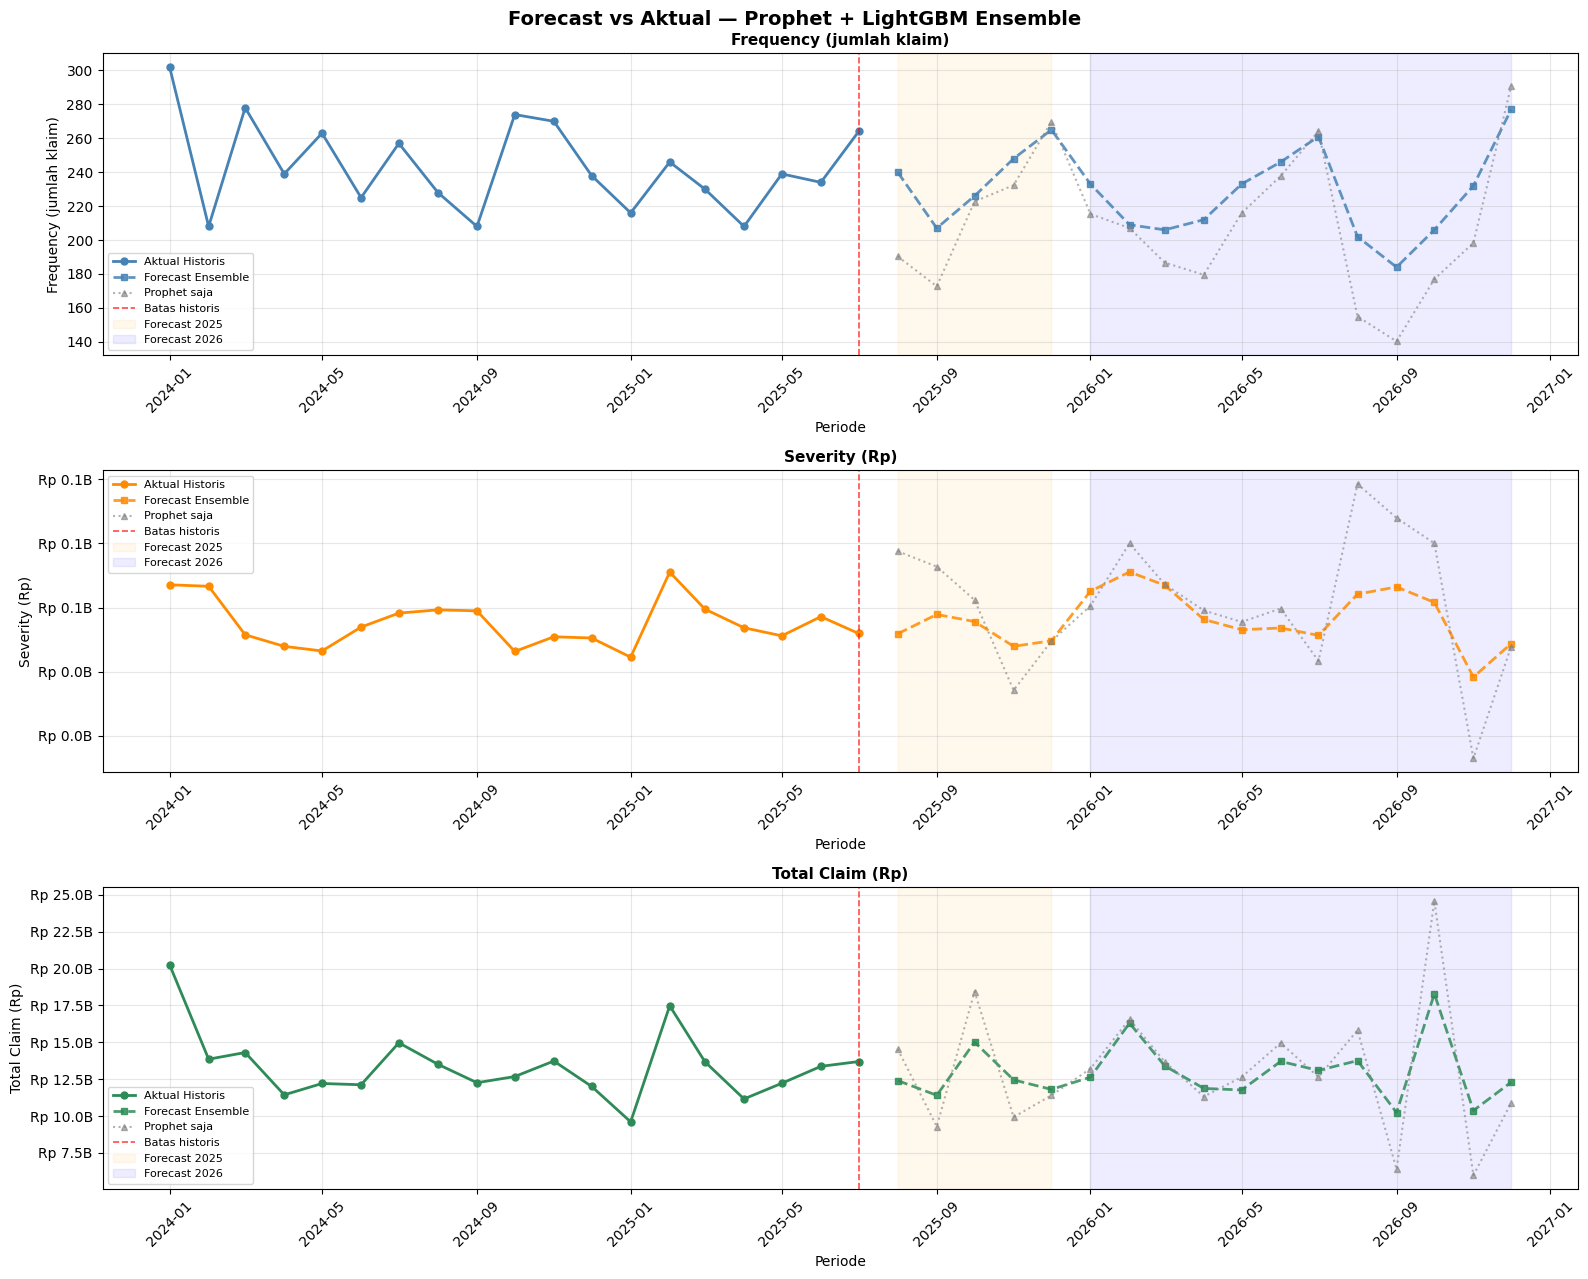

Plot tersimpan sebagai forecast_plot.png


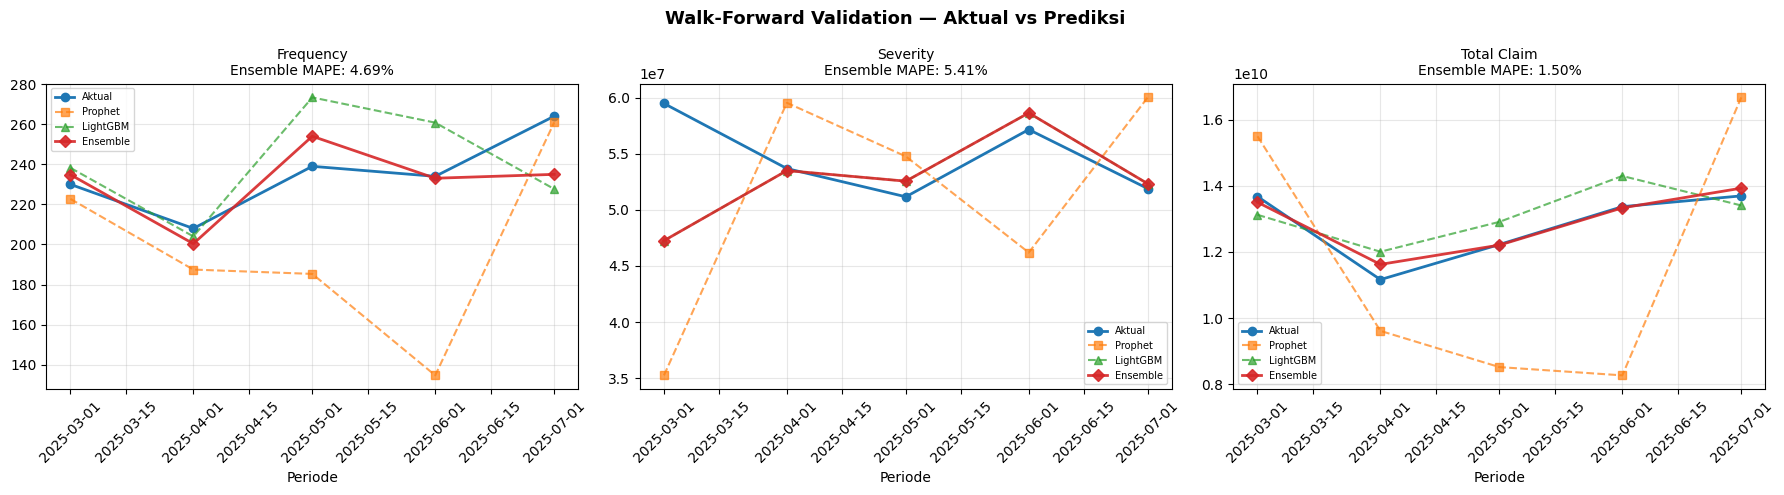

Plot validasi tersimpan sebagai validation_plot.png

Pipeline selesai.


In [11]:
# ── FORECAST PANJANG: AGUSTUS 2025 S/D DESEMBER 2026 ──
future_steps_2026 = 17
temp_df_long      = full_df.copy()
avg_exposure      = full_df['Exposure'].iloc[-3:].mean()

results_freq_long  = []
results_sev_long   = []
results_total_long = []
periods_long       = []

print("=" * 50)
print("FORECAST PANJANG — Agustus 2025 s/d Desember 2026")
print("=" * 50)

for step in range(future_steps_2026):
    next_period = (
        temp_df_long['Periode_Klaim'].max() + pd.DateOffset(months=1)
    )

    new_feat, next_tidx, next_month, next_quarter = build_future_features(
        temp_df_long, next_period, avg_exposure
    )
    X_next = pd.DataFrame([new_feat])

    # ── LightGBM prediksi ──────────────────────────────
    p_freq_lgbm  = lgbm_model_freq.predict(X_next[FEATURES_FREQ])[0]
    p_sev_lgbm   = lgbm_model_sev.predict(X_next[FEATURES_SEV])[0]
    p_total_lgbm = lgbm_model_total.predict(X_next[FEATURES_TOTAL])[0]

    # ── Prophet prediksi ───────────────────────────────
    future_prophet  = pd.DataFrame({'ds': [next_period]})
    p_freq_prophet  = prophet_model_freq.predict(future_prophet)['yhat'].iloc[0]
    p_sev_prophet   = prophet_model_sev.predict(future_prophet)['yhat'].iloc[0]
    p_total_prophet = prophet_model_total.predict(future_prophet)['yhat'].iloc[0]

    # ── Ensemble dengan progressive Prophet weight ─────
    # Semakin jauh horizon, Prophet makin dominan karena
    # lebih stabil untuk ekstrapolasi jangka panjang
    horizon_weight = min(step / future_steps_2026, 0.3)

    w_p_freq  = min(ensemble_weights['freq']['prophet']  + horizon_weight, 1.0)
    w_p_sev   = min(ensemble_weights['sev']['prophet']   + horizon_weight, 1.0)
    w_p_total = min(ensemble_weights['total']['prophet'] + horizon_weight, 1.0)

    p_freq  = (w_p_freq  * p_freq_prophet  + (1 - w_p_freq)  * p_freq_lgbm)
    p_sev   = (w_p_sev   * p_sev_prophet   + (1 - w_p_sev)   * p_sev_lgbm)
    p_total = (w_p_total * p_total_prophet + (1 - w_p_total) * p_total_lgbm)

    # Safety clip
    p_freq  = max(0, p_freq)
    p_sev   = max(0, p_sev)
    p_total = max(0, p_total)

    results_freq_long.append(p_freq)
    results_sev_long.append(p_sev)
    results_total_long.append(p_total)
    periods_long.append(next_period)

    print(f"Step {step+1:2d} | {next_period.strftime('%Y-%m')} | "
          f"Freq: {p_freq:.0f} | "
          f"Sev: {p_sev:,.0f} | "
          f"Total: {p_total:,.0f}")

    # Update temp_df_long
    new_row = {
        'Periode_Klaim'      : next_period,
        'Claim_Frequency'    : p_freq,
        'Claim_Severity_wins': p_sev,
        'Total_Claim_wins'   : p_total,
        'Claim_Severity'     : p_sev,
        'Total_Claim'        : p_total,
        'Time_Index'         : next_tidx,
        'Month'              : next_month,
        'Quarter'            : next_quarter,
        'Exposure'           : avg_exposure,
        'Claim_Rate'         : p_freq / avg_exposure,
    }
    for col in temp_df_long.columns:
        if col not in new_row:
            new_row[col] = 0

    temp_df_long = pd.concat(
        [temp_df_long, pd.DataFrame([new_row])],
        ignore_index=True
    )

# ── SUSUN HASIL ────────────────────────────────────────
df_forecast_long = pd.DataFrame({
    'Periode'        : periods_long,
    'Claim_Frequency': np.round(results_freq_long).astype(int),
    'Claim_Severity' : np.round(results_sev_long),
    'Total_Claim'    : np.round(results_total_long),
})

df_forecast_2025 = df_forecast_long[
    df_forecast_long['Periode'].dt.year == 2025
]
df_forecast_2026 = df_forecast_long[
    df_forecast_long['Periode'].dt.year == 2026
]

print("\n" + "=" * 50)
print("PREDIKSI AGUSTUS–DESEMBER 2025")
print("=" * 50)
display(df_forecast_2025)

print("\n" + "=" * 50)
print("PREDIKSI JANUARI–DESEMBER 2026")
print("=" * 50)
display(df_forecast_2026)

print("\n" + "=" * 50)
print("RINGKASAN TAHUNAN 2026")
print("=" * 50)
print(f"Total Frequency   : {df_forecast_2026['Claim_Frequency'].sum():,.0f} klaim")
print(f"Rata-rata Severity: Rp {df_forecast_2026['Claim_Severity'].mean():,.0f}")
print(f"Total Claim 2026  : Rp {df_forecast_2026['Total_Claim'].sum():,.0f}")

# ── VISUALISASI FORECAST VS AKTUAL ─────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 13))
fig.suptitle(
    'Forecast vs Aktual — Prophet + LightGBM Ensemble',
    fontsize=14, fontweight='bold'
)

plot_targets = [
    ('Claim_Frequency', 'Claim_Frequency',   'Frequency (jumlah klaim)', 'steelblue'),
    ('Claim_Severity',  'Claim_Severity_wins','Severity (Rp)',            'darkorange'),
    ('Total_Claim',     'Total_Claim_wins',   'Total Claim (Rp)',         'seagreen'),
]

for ax, (fc_col, ac_col, ylabel, color) in zip(axes, plot_targets):
    # Aktual historis
    ax.plot(
        full_df['Periode_Klaim'],
        full_df[ac_col],
        color=color, linewidth=2,
        marker='o', markersize=5,
        label='Aktual Historis'
    )

    # Forecast ensemble
    ax.plot(
        df_forecast_long['Periode'],
        df_forecast_long[fc_col],
        color=color, linewidth=2,
        linestyle='--', marker='s',
        markersize=5, alpha=0.85,
        label='Forecast Ensemble'
    )

    # Prophet saja (perbandingan)
    future_dates   = pd.DataFrame({'ds': df_forecast_long['Periode']})
    if fc_col == 'Claim_Frequency':
        prophet_only = prophet_model_freq.predict(future_dates)['yhat'].values
    elif fc_col == 'Claim_Severity':
        prophet_only = prophet_model_sev.predict(future_dates)['yhat'].values
    else:
        prophet_only = prophet_model_total.predict(future_dates)['yhat'].values

    ax.plot(
        df_forecast_long['Periode'],
        np.clip(prophet_only, 0, None),
        color='gray', linewidth=1.5,
        linestyle=':', marker='^',
        markersize=4, alpha=0.6,
        label='Prophet saja'
    )

    # Garis batas historis
    ax.axvline(
        x=full_df['Periode_Klaim'].max(),
        color='red', linestyle='--',
        linewidth=1.2, alpha=0.7,
        label='Batas historis'
    )

    # Shading 2025 sisa
    if len(df_forecast_2025) > 0:
        ax.axvspan(
            df_forecast_2025['Periode'].min(),
            df_forecast_2025['Periode'].max(),
            alpha=0.07, color='orange',
            label='Forecast 2025'
        )

    # Shading 2026
    if len(df_forecast_2026) > 0:
        ax.axvspan(
            df_forecast_2026['Periode'].min(),
            df_forecast_2026['Periode'].max(),
            alpha=0.07, color='blue',
            label='Forecast 2026'
        )

    ax.set_title(ylabel, fontsize=11, fontweight='bold')
    ax.set_xlabel('Periode')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

    if fc_col != 'Claim_Frequency':
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'Rp {x/1e9:.1f}B')
        )

plt.tight_layout()
plt.savefig('forecast_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot tersimpan sebagai forecast_plot.png")

# ── VISUALISASI WALK-FORWARD VALIDATION ───────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle(
    'Walk-Forward Validation — Aktual vs Prediksi',
    fontsize=13, fontweight='bold'
)

val_periods = [s[1]['Periode_Klaim'].iloc[0] for s in splits]

val_data = [
    ('Frequency',
     prophet_val_results['actual_freq'],
     prophet_val_results['freq_preds'],
     lgbm_val_results['freq_preds'],
     ensemble_weights['freq']),
    ('Severity',
     prophet_val_results['actual_sev'],
     prophet_val_results['sev_preds'],
     lgbm_val_results['sev_preds'],
     ensemble_weights['sev']),
    ('Total Claim',
     prophet_val_results['actual_total'],
     prophet_val_results['total_preds'],
     lgbm_val_results['total_preds'],
     ensemble_weights['total']),
]

for ax, (title, actuals, p_preds, l_preds, weights) in zip(axes2, val_data):
    ens_preds = np.clip(
        weights['prophet'] * np.array(p_preds) +
        weights['lgbm']    * np.array(l_preds),
        0, None
    )

    ax.plot(val_periods, actuals,   'o-',  label='Aktual',   linewidth=2)
    ax.plot(val_periods, p_preds,   's--', label='Prophet',  linewidth=1.5, alpha=0.7)
    ax.plot(val_periods, l_preds,   '^--', label='LightGBM', linewidth=1.5, alpha=0.7)
    ax.plot(val_periods, ens_preds, 'D-',  label='Ensemble', linewidth=2,   alpha=0.9)

    mape_val = safe_mape(actuals, ens_preds)
    ax.set_title(f'{title}\nEnsemble MAPE: {mape_val:.2f}%', fontsize=10)
    ax.set_xlabel('Periode')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('validation_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot validasi tersimpan sebagai validation_plot.png")

print("\nPipeline selesai.")